## Correct p(mag,rad|Teff,KOI, R) / p(mag,rad|Teff,R)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from plotutils import *
from pdetutils import *
from magutils import *

import seaborn as sns
sns.set(style='ticks', font_scale=1.6, font='times')
plt.rcParams["figure.figsize"] = (10,6)
from matplotlib import rc
rc('text', usetex=False)
import warnings
warnings.filterwarnings("ignore")

In [2]:
lmag = r'\textit{Kepler} magnitude $K_p$'
llogr = '$\log_{10} r$ (ppm)'
ckic = 'gray'
ckoi = 'salmon'
figdir = 'figs'

In [3]:
def sample_dkic_pi(dkic, pdetsampler):
    piD = pdetsampler.sample(dkic.logr, dkic.kepmag, dkic.Teff, dkic.rad)

    idx = np.random.choice(np.arange(len(dkic)), size=len(dkic), p=piD/np.sum(piD))
    dkic_pi = dkic.iloc[idx].reset_index(drop=True)

    return dkic_pi

def get_resampled_kic(dkic_pi, dkoi, teff_bins):
    dkic_smp = sample_near_dkoiR(dkic_pi, dkoi, teff_bins)
    return dkic_smp


def check_mag_dists(dkic, dkoi, teff_bins, dkic_orig=None):
    bins = np.linspace(9, 16, 100)
    for i in range(len(teff_bins)-1):
        tlo, thi = teff_bins[i], teff_bins[i+1]
        plt.figure()
        plt.title(f"Teff={tlo}-{thi}K")
        idx = (tlo < dkic.Teff) & (dkic.Teff <= thi)
        plt.hist(dkic.kepmag[idx], histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'resampled KIC ({np.sum(idx)})')
        idx = (tlo < dkoi.Teff) & (dkoi.Teff <= thi)
        plt.hist(dkoi.kepmag[idx], histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'KOI ({np.sum(idx)})')
        if dkic_orig is not None:
            idx = (tlo < dkic_orig.Teff) & (dkic_orig.Teff <= thi)
            plt.hist(dkic_orig.kepmag[idx], histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'original KIC ({np.sum(idx)})', color='gray')
        plt.legend(loc='best')


def check_rad_dists(dkic, dkoi, teff_bins, dkic_orig=None):
    bins = np.linspace(-0.5, 1, 100)
    for i in range(len(teff_bins)-1):
        tlo, thi = teff_bins[i], teff_bins[i+1]
        plt.figure()
        plt.title(f"Teff={tlo}-{thi}K")
        idx = (tlo < dkic.Teff) & (dkic.Teff <= thi)
        plt.hist(np.log10(dkic.rad[idx]), histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'resampled KIC ({np.sum(idx)})')
        idx = (tlo < dkoi.Teff) & (dkoi.Teff <= thi)
        plt.hist(np.log10(dkoi.rad[idx]), histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'KOI ({np.sum(idx)})')
        if dkic_orig is not None:
            idx = (tlo < dkic_orig.Teff) & (dkic_orig.Teff <= thi)
            plt.hist(np.log10(dkic_orig.rad[idx]), histtype='step', lw=1, bins=bins, cumulative=True, density=True, label=f'original KIC ({np.sum(idx)})', color='gray')
        plt.legend(loc='best')

In [4]:
datadir = 'data_m15/'
dkoi = pd.read_csv(datadir+"m15_koi.csv")
#dkic = pd.read_csv(datadir+"m15_kic.csv")
dkic = pd.read_csv("m15_kic_w_pdet_TR.csv")

dkicrad = pd.read_csv("data/DR2PapTable1.txt", delimiter='&')
dkoi = pd.merge(dkoi, dkicrad[['KIC', 'rad']], on='KIC')

pdetsampler = PdetSamplerR(dkic)
teff_bins = np.arange(3500, 6501, 100)

In [5]:
dkic_pi = sample_dkic_pi(dkic, pdetsampler)

In [6]:
dkic_smp = get_resampled_kic(dkic_pi, dkoi, teff_bins)

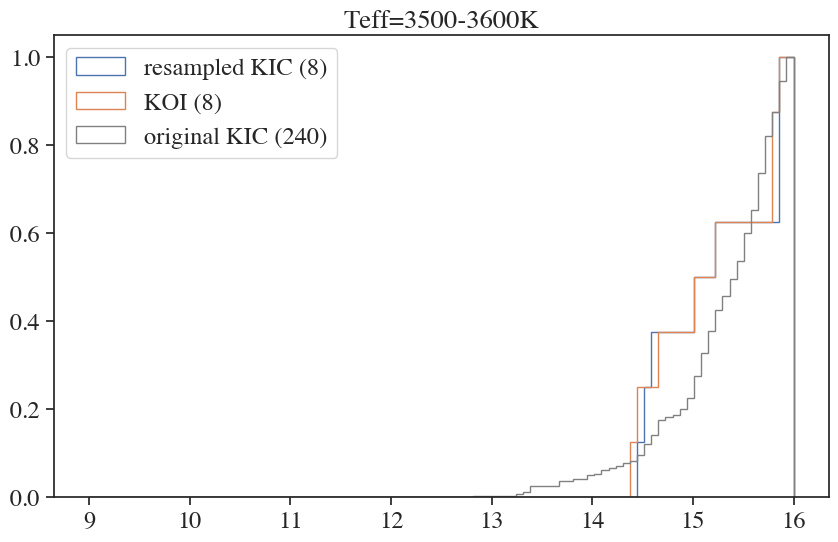

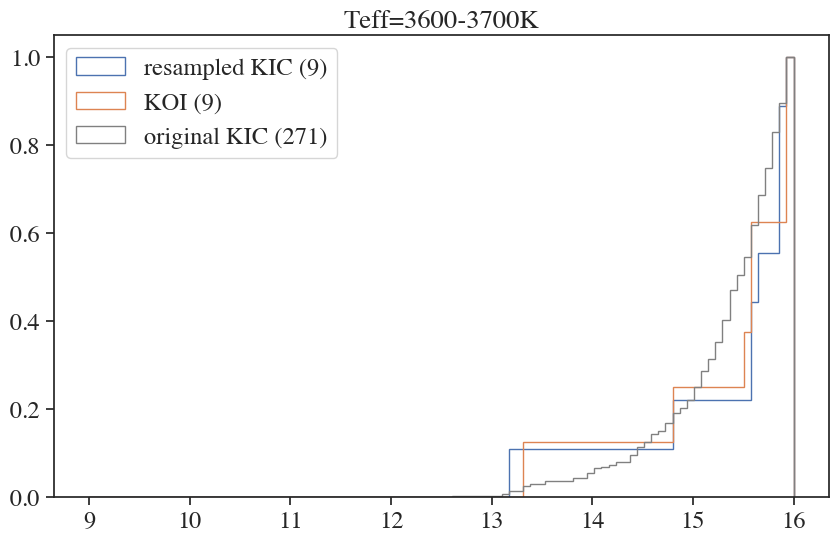

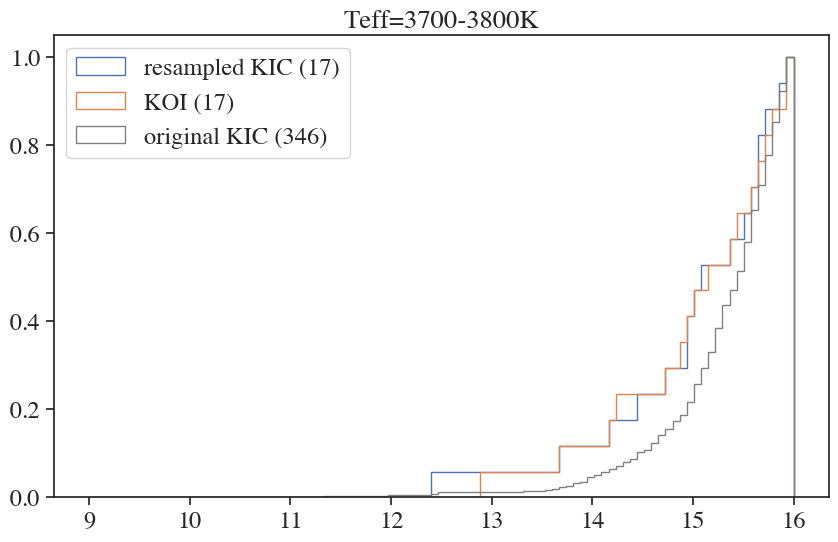

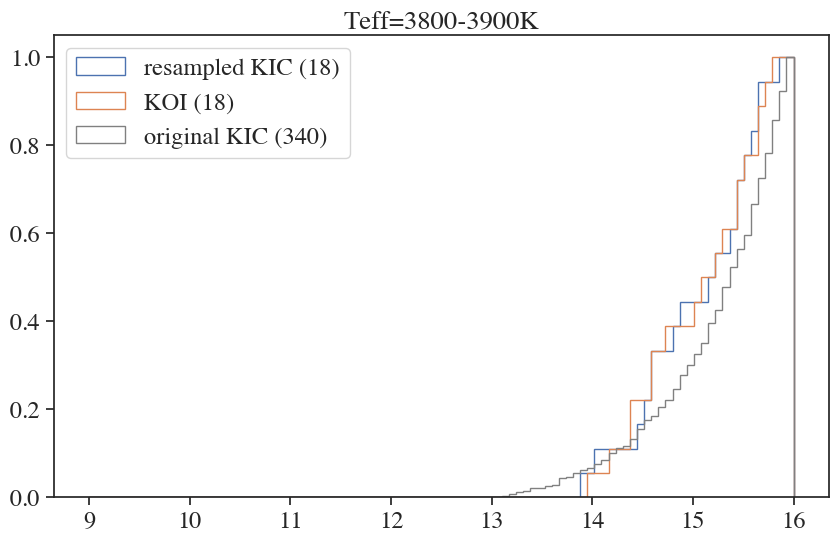

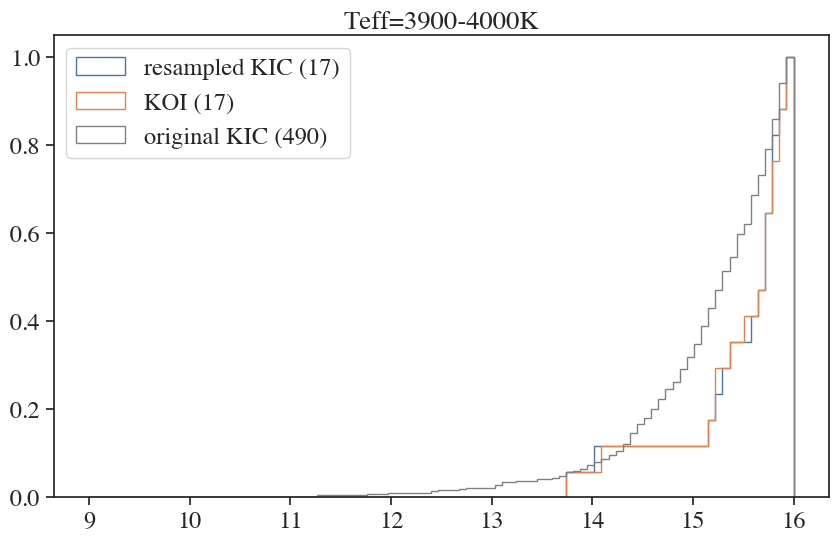

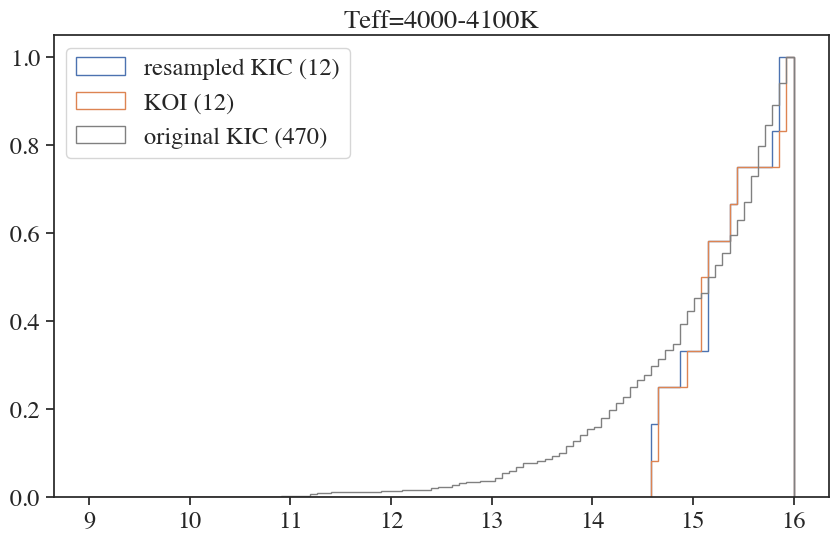

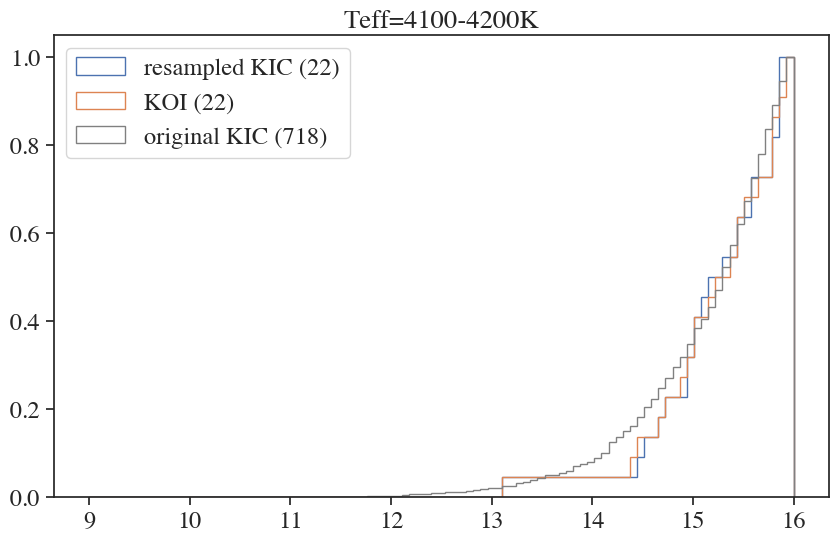

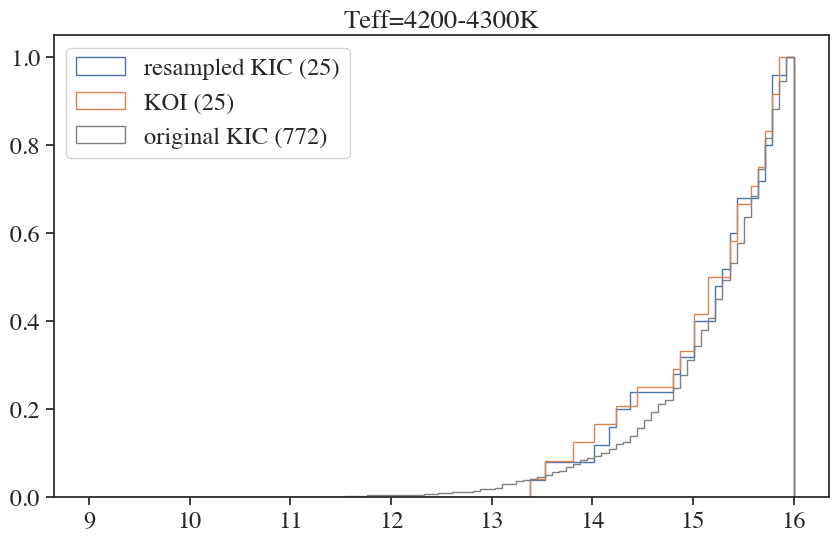

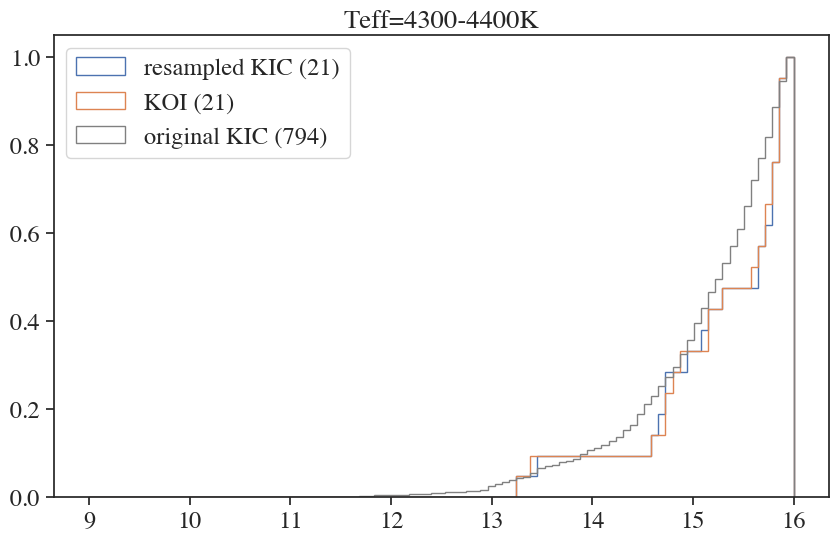

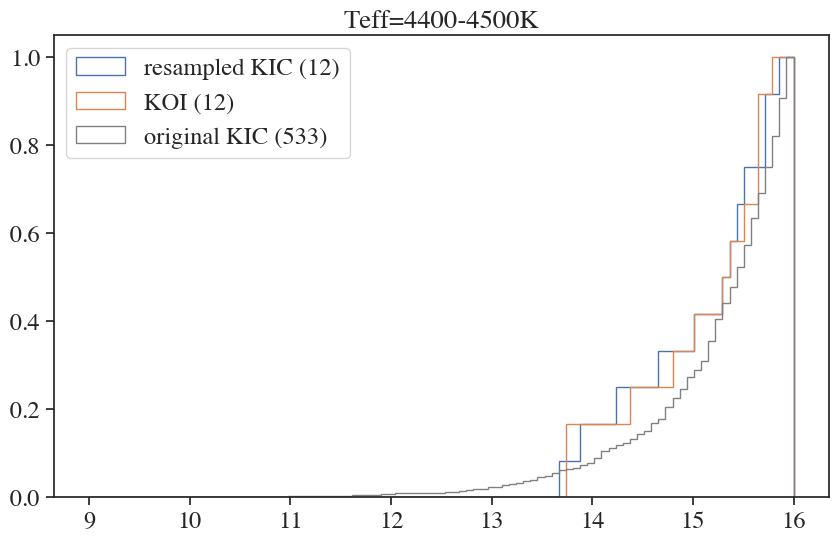

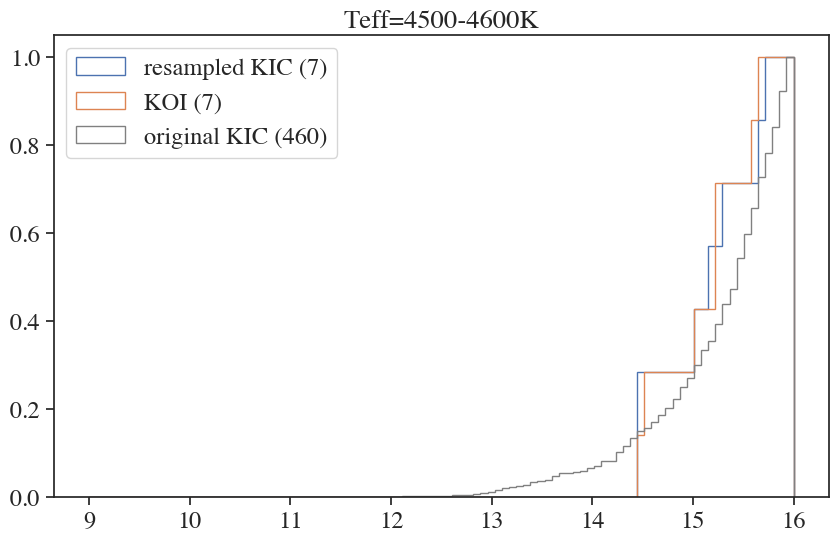

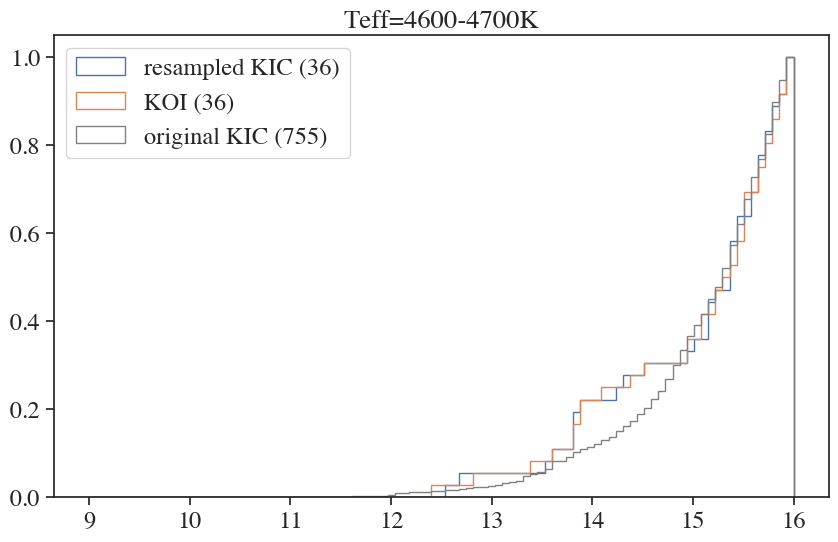

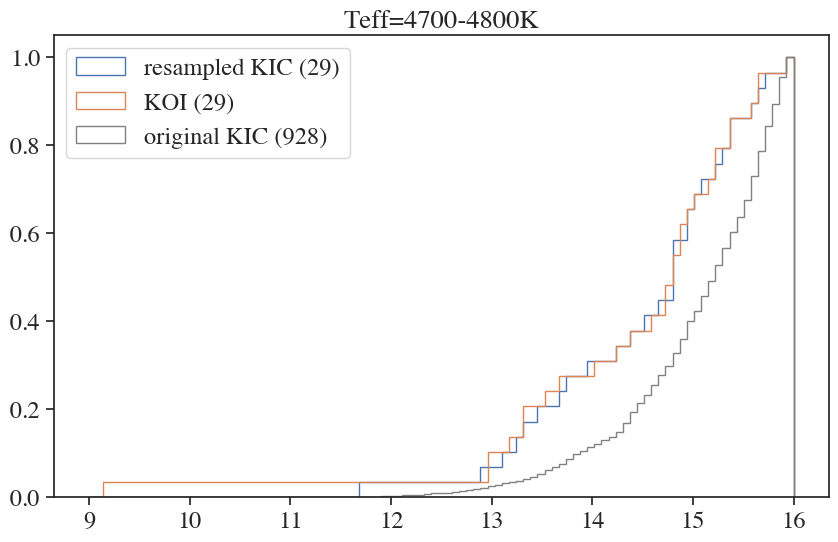

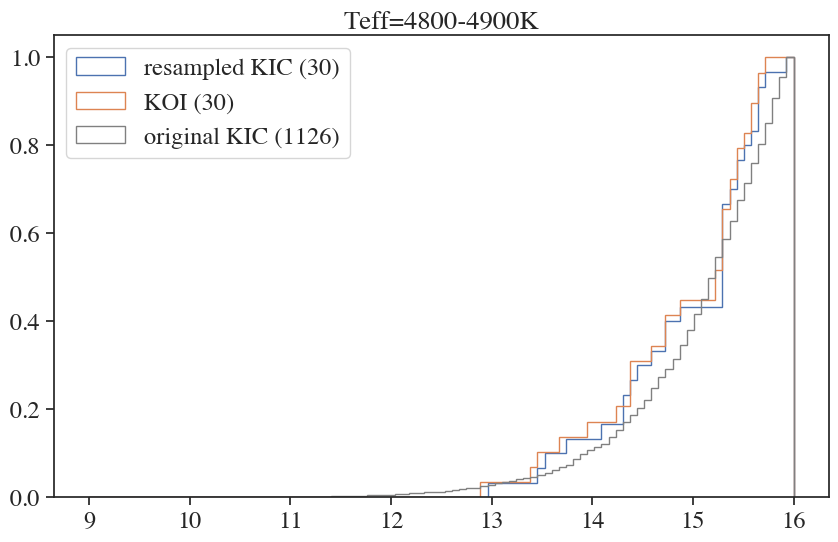

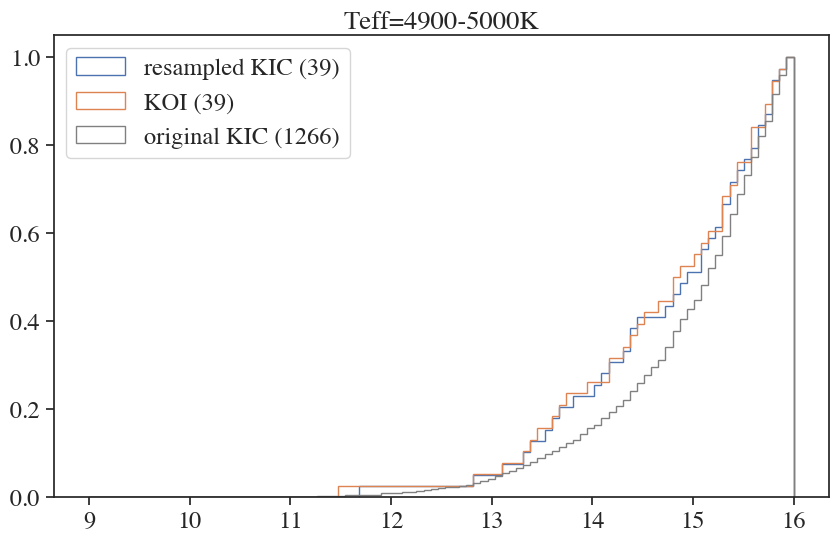

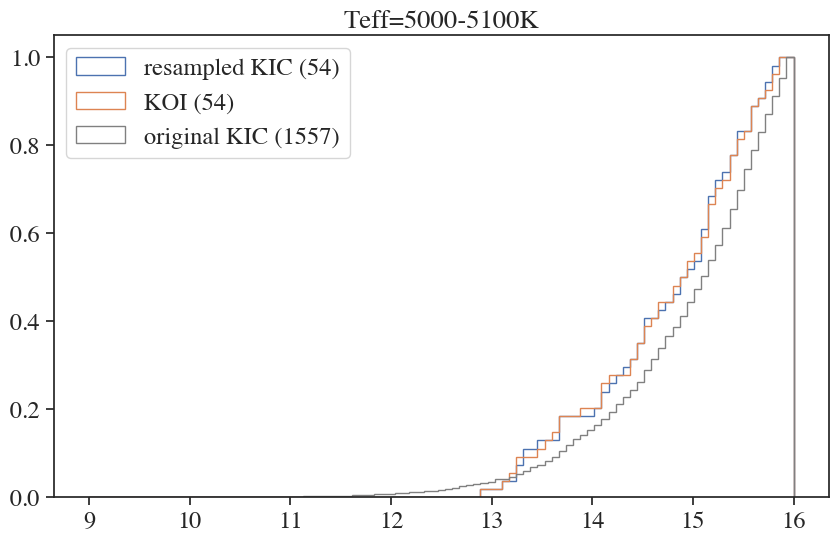

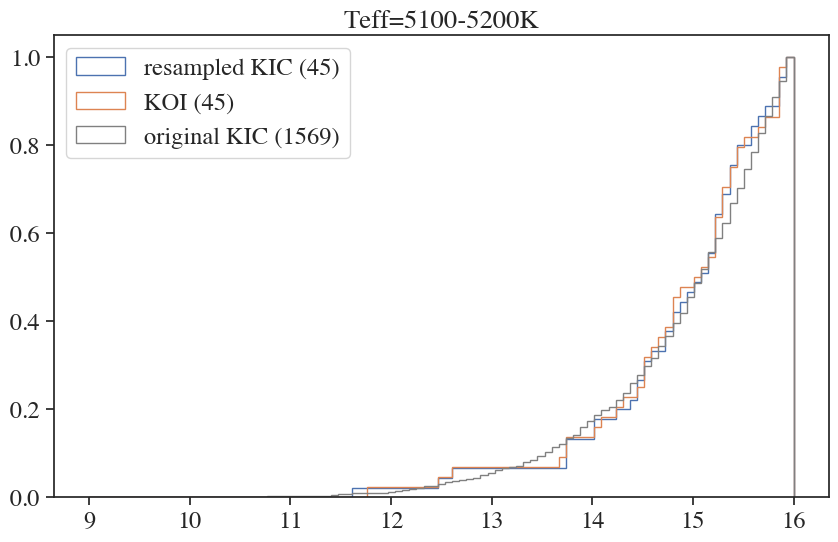

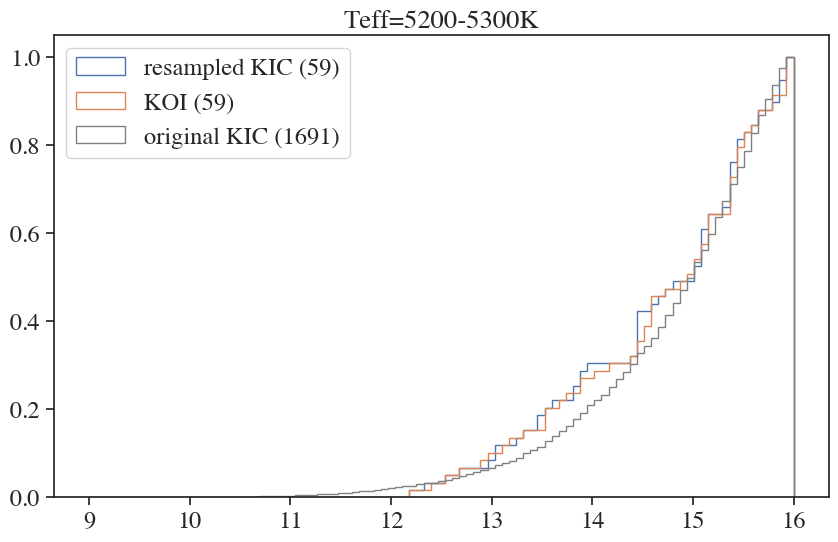

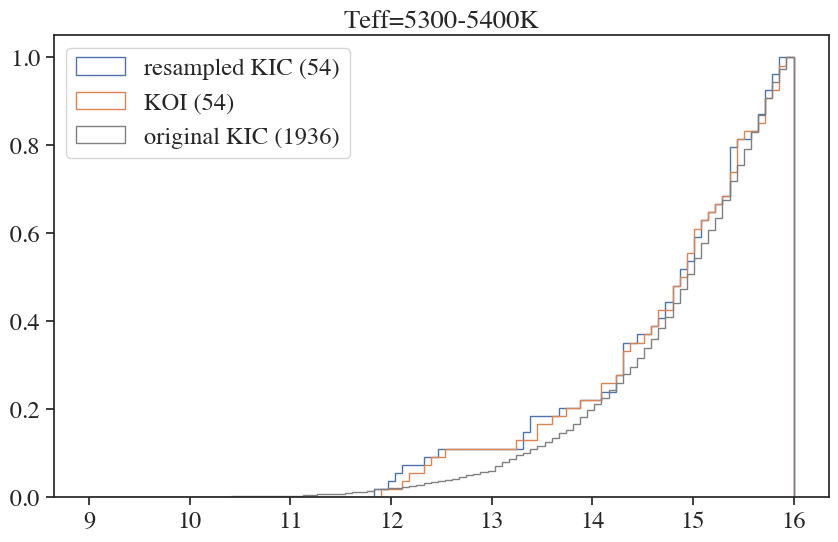

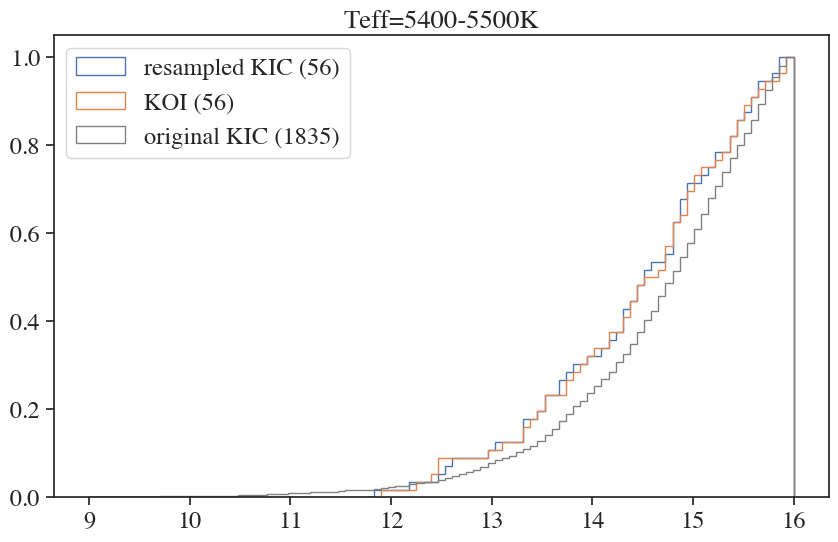

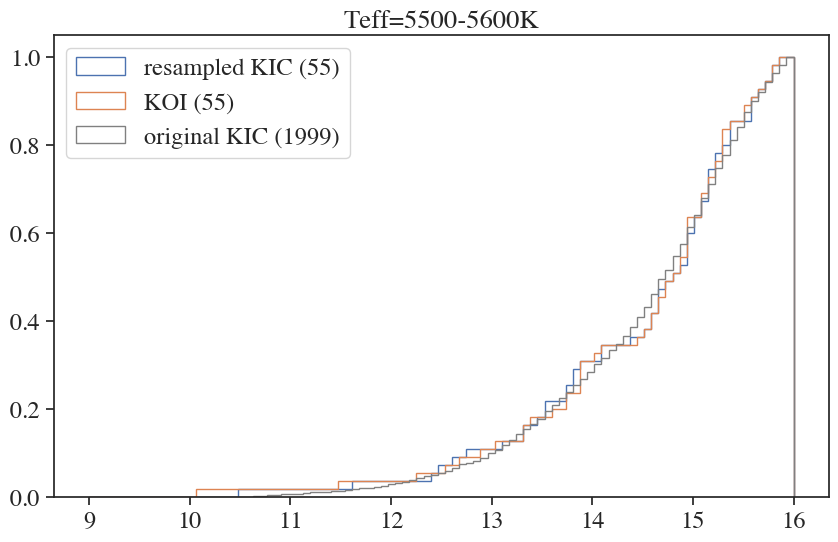

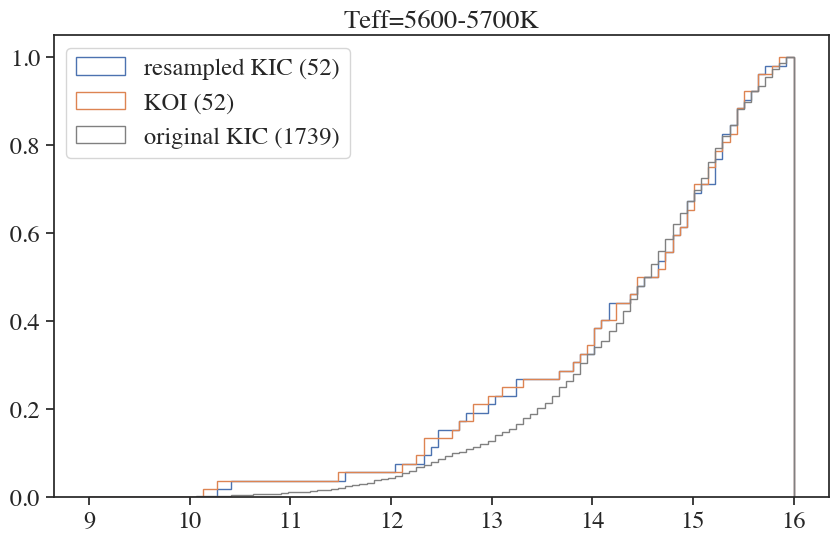

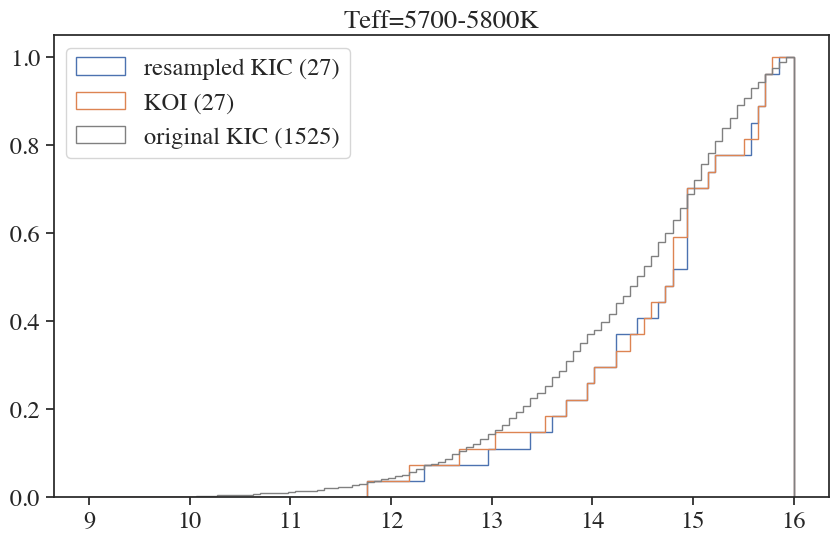

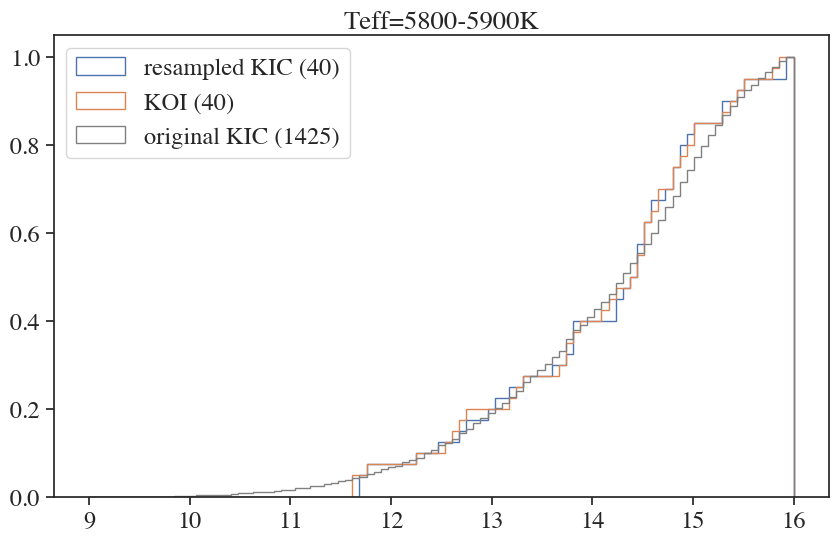

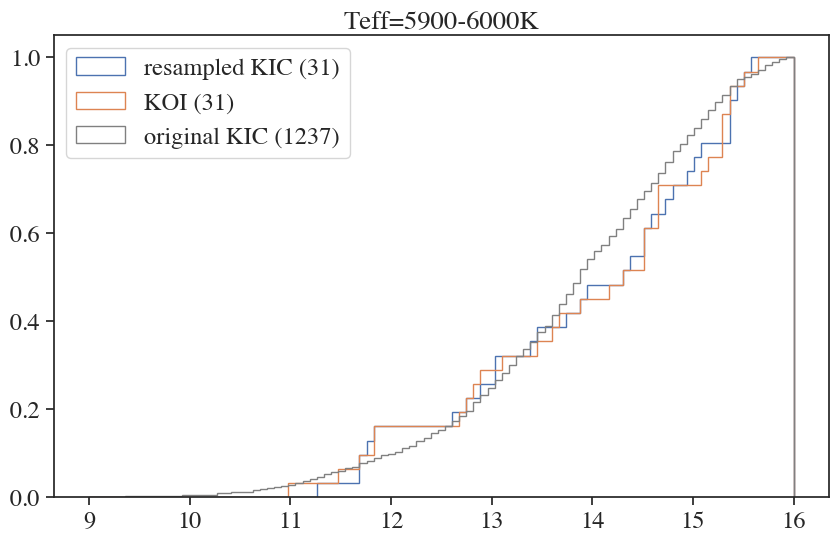

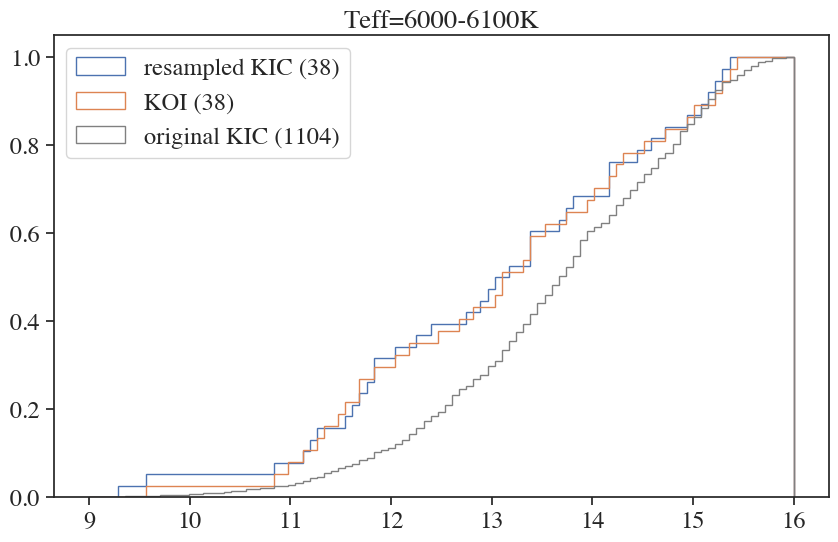

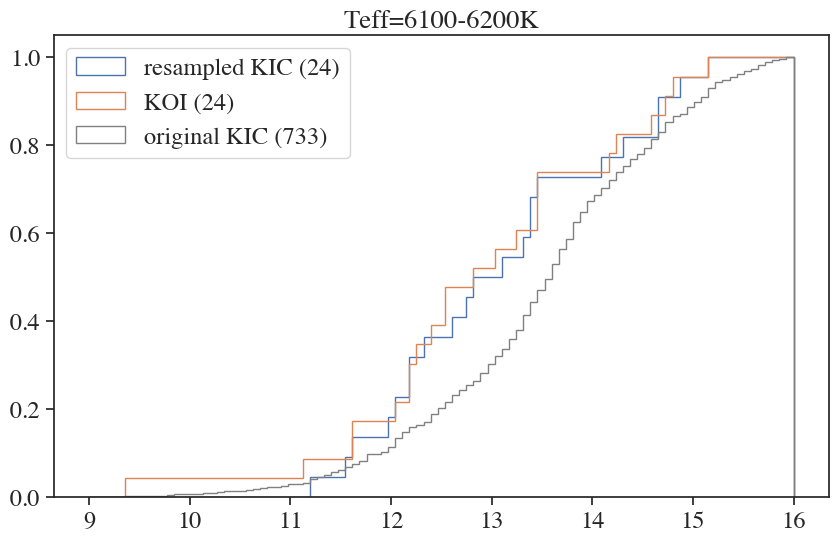

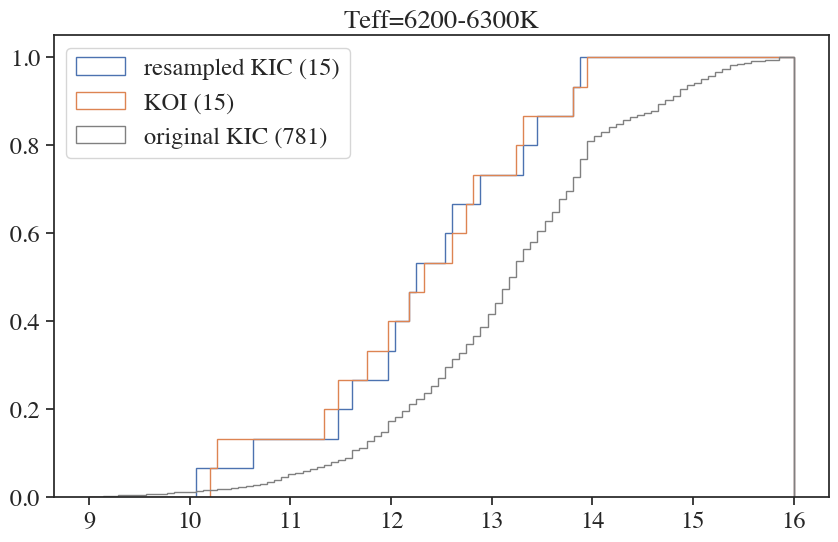

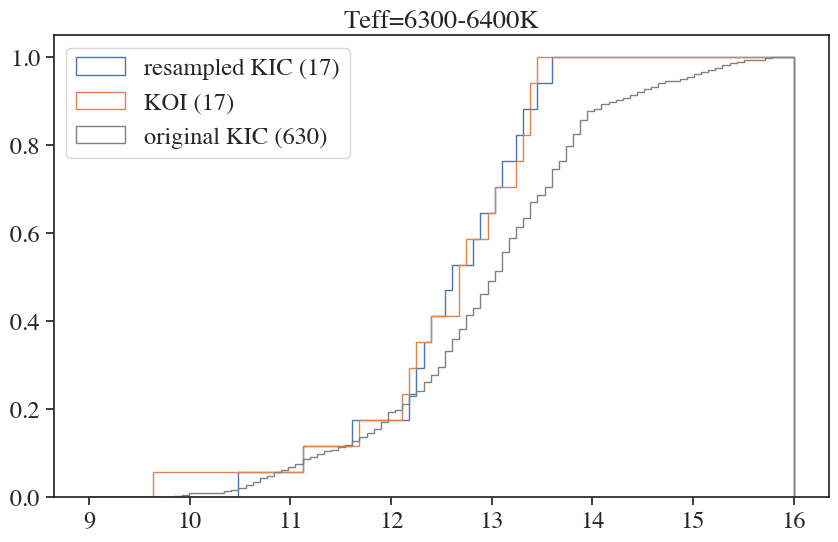

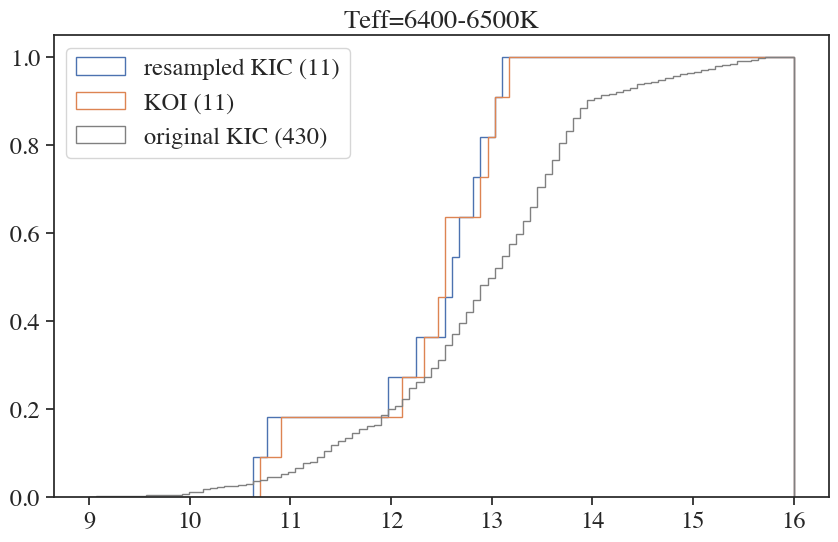

In [7]:
check_mag_dists(dkic_smp, dkoi, teff_bins, dkic_orig=dkic)

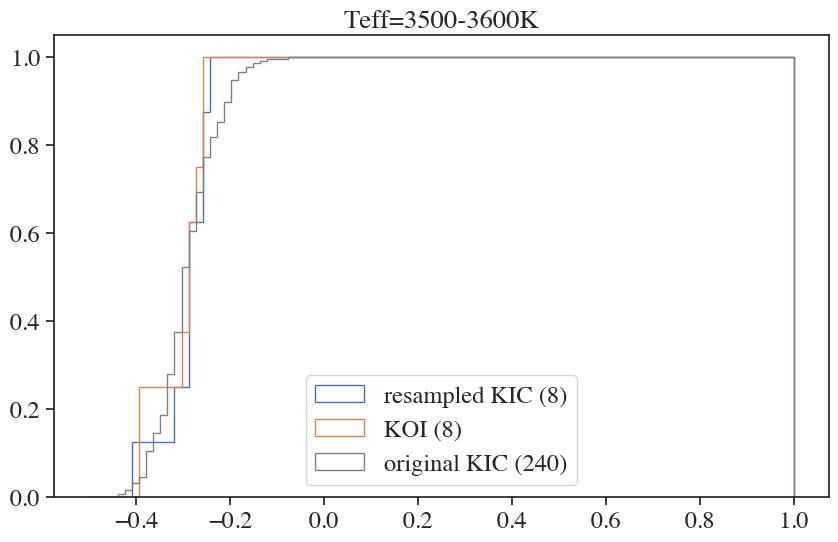

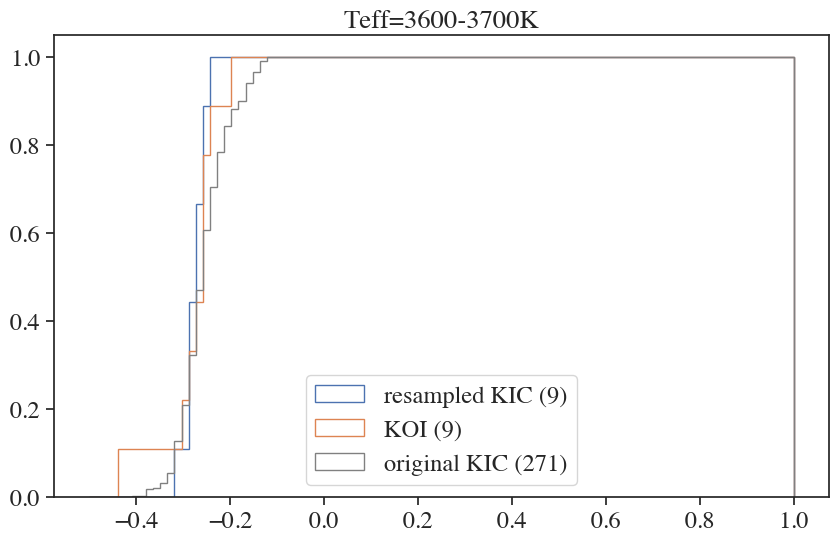

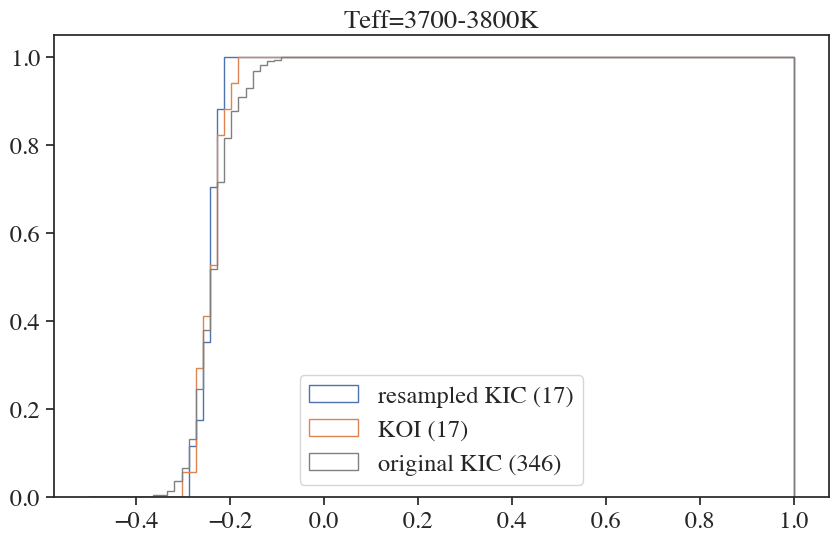

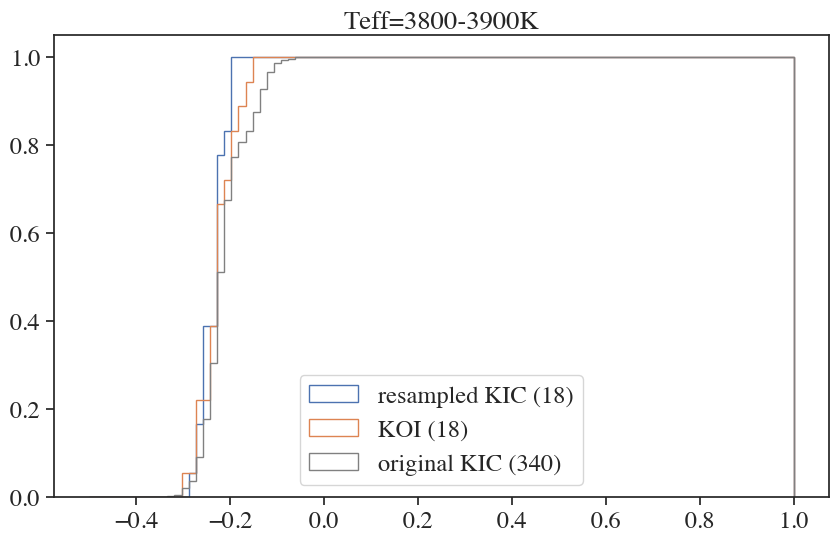

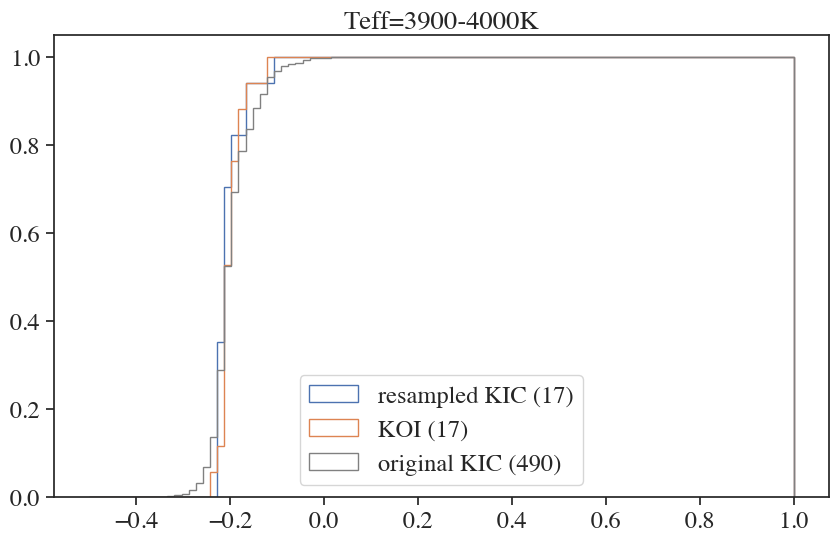

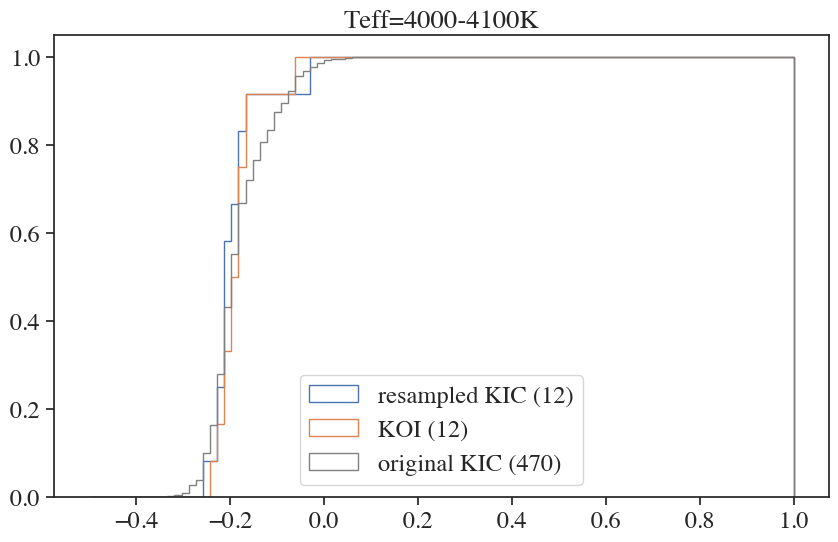

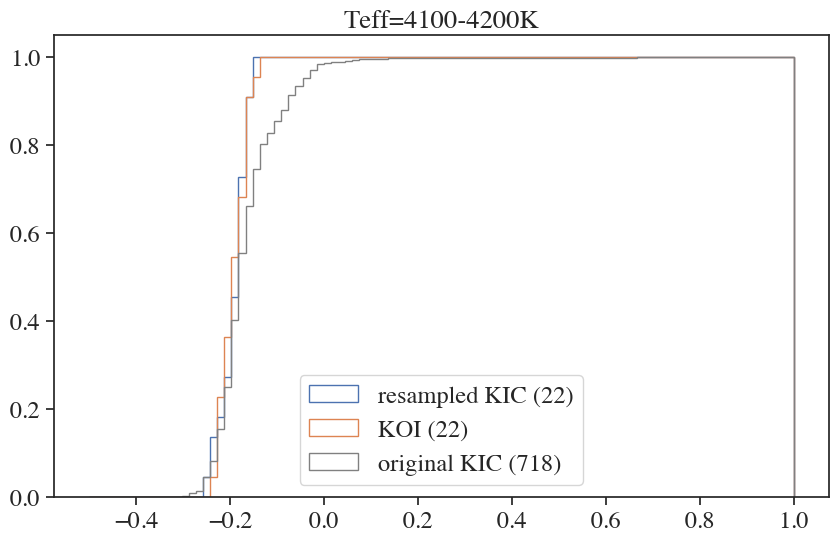

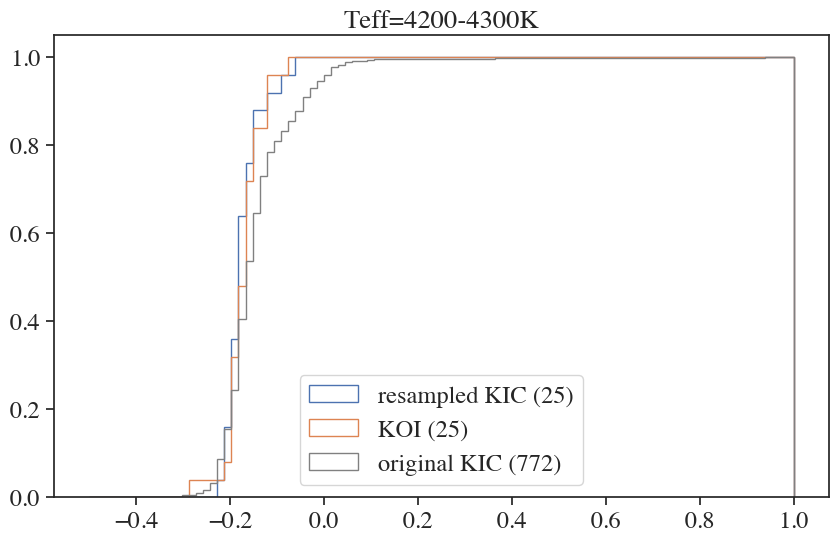

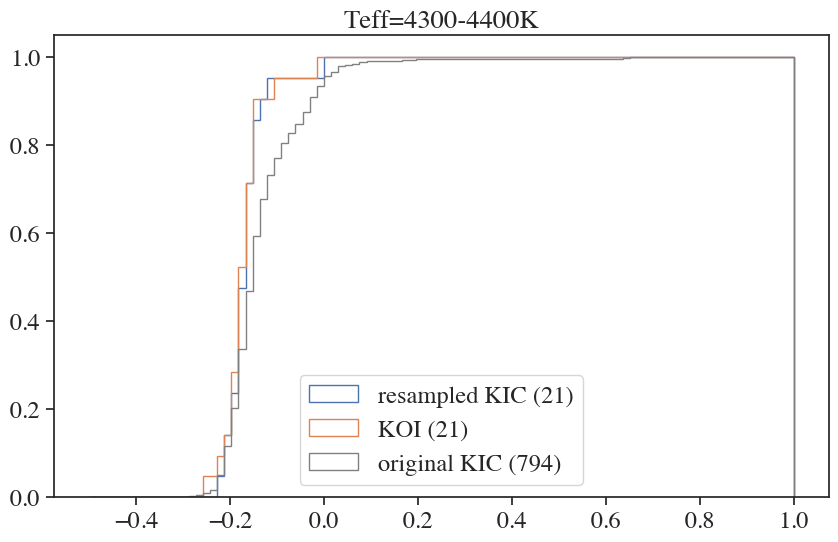

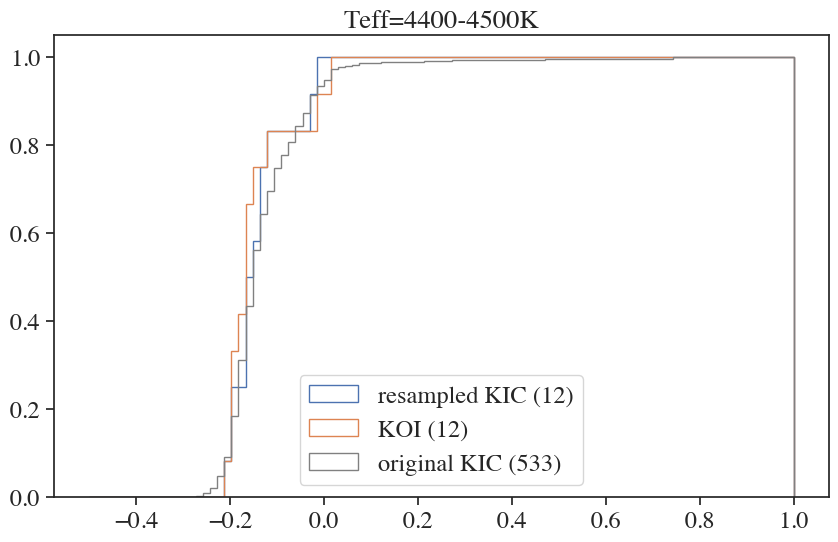

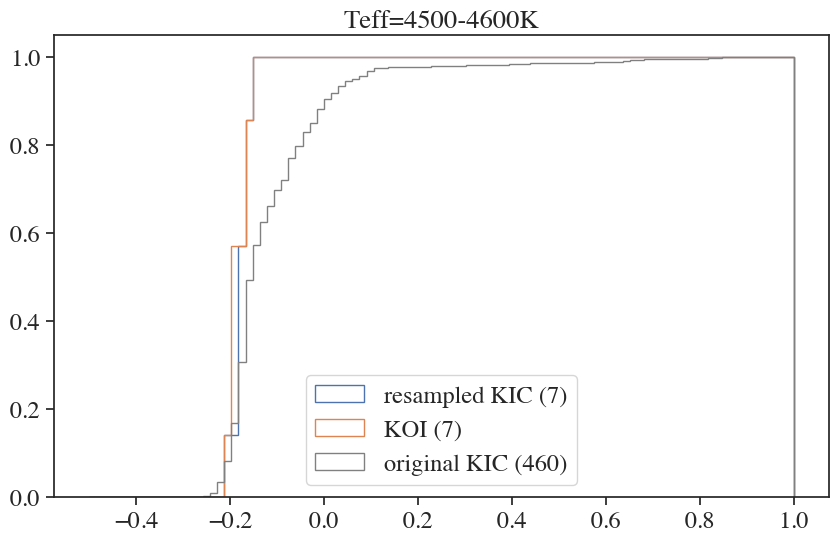

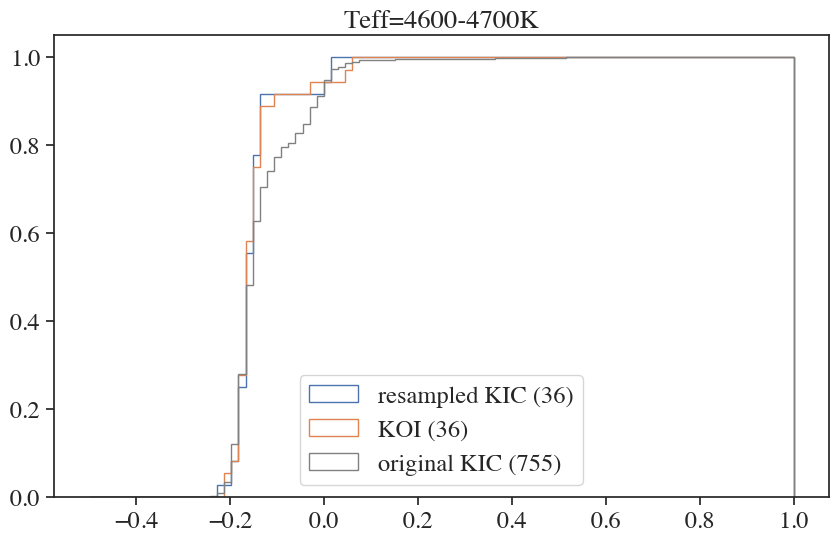

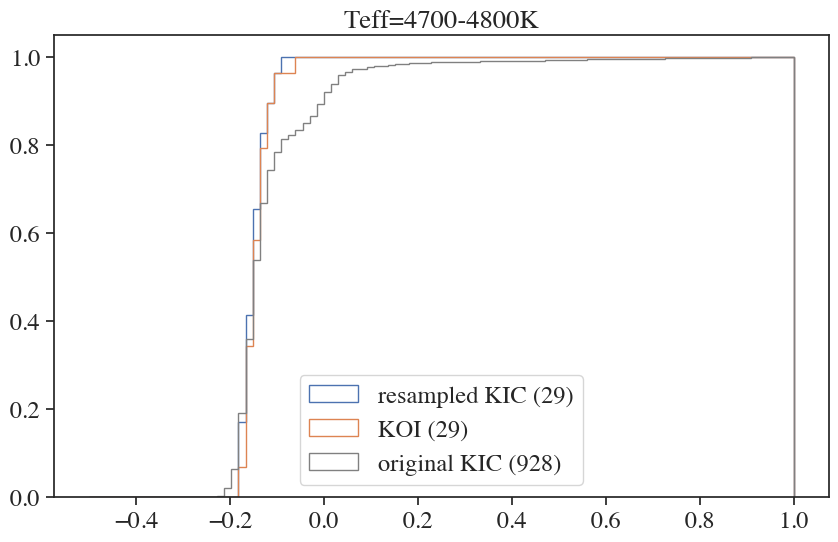

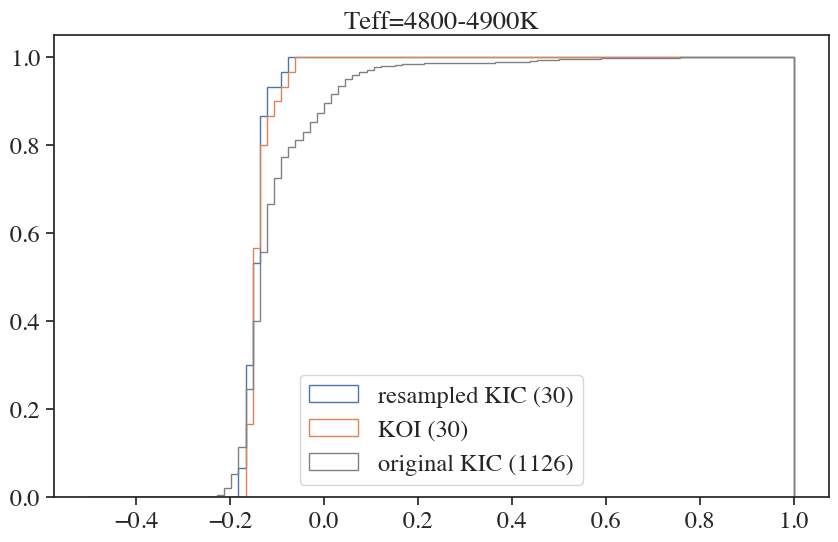

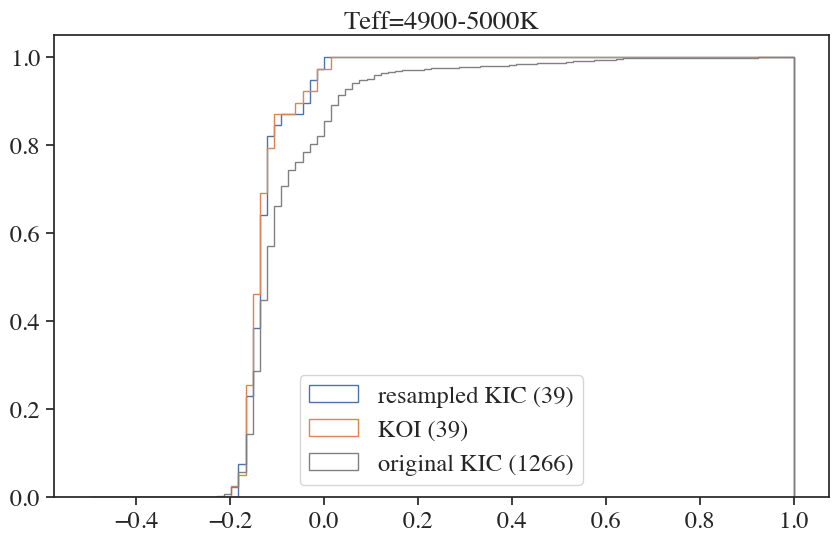

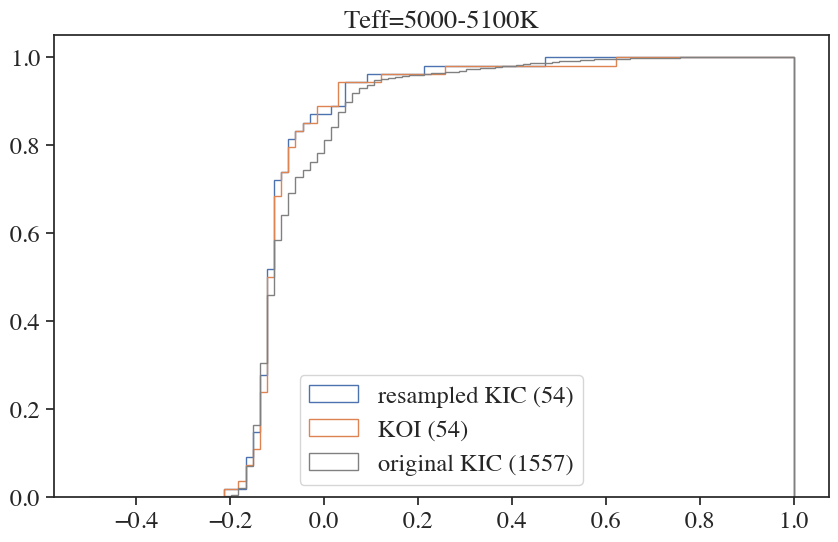

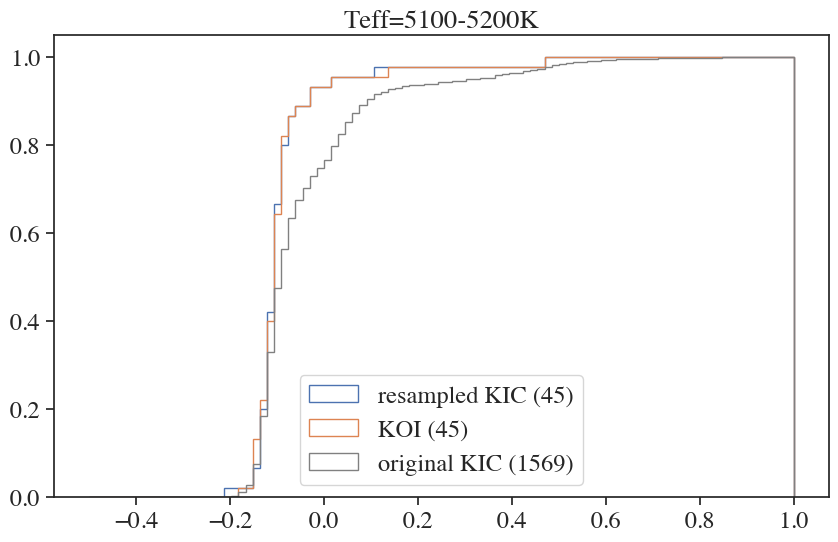

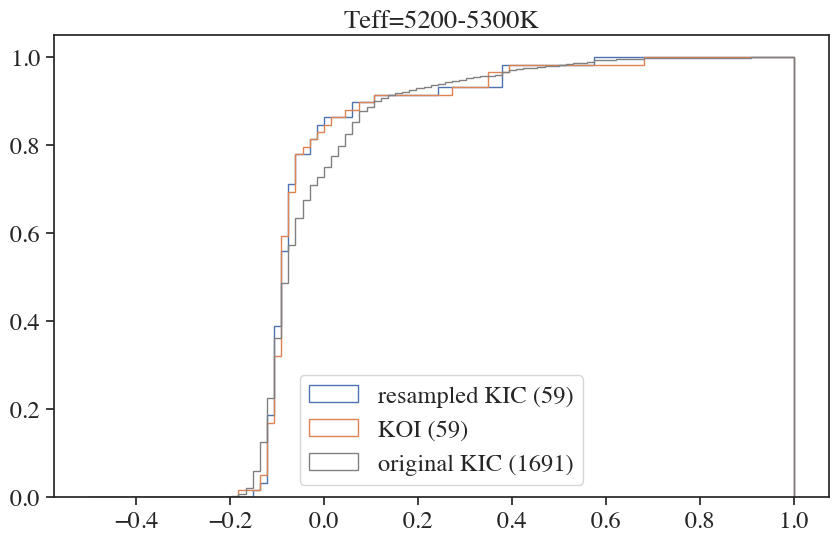

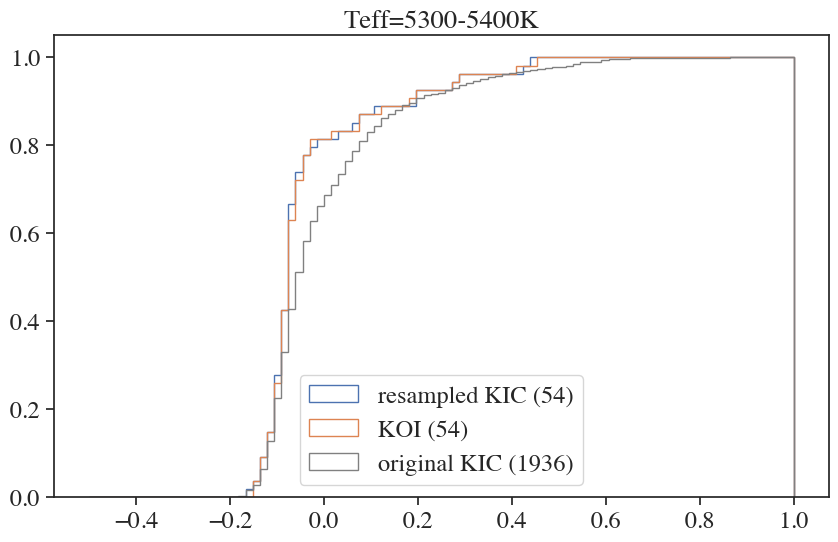

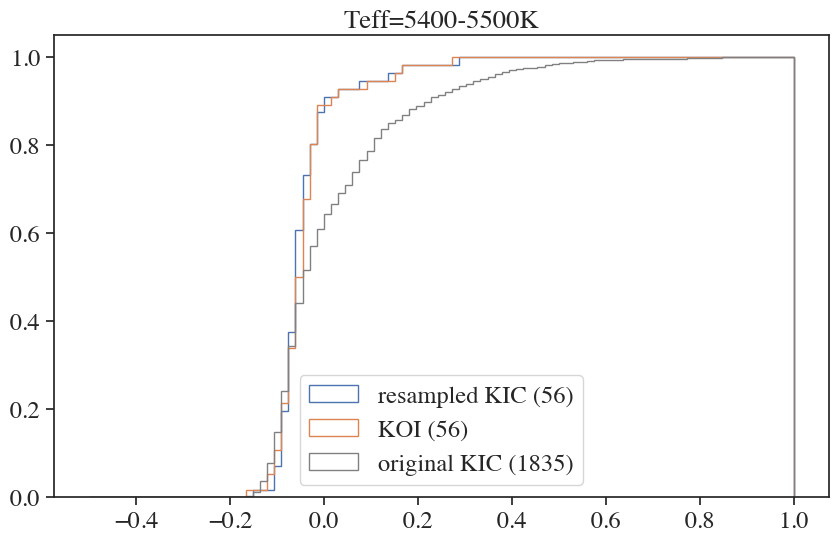

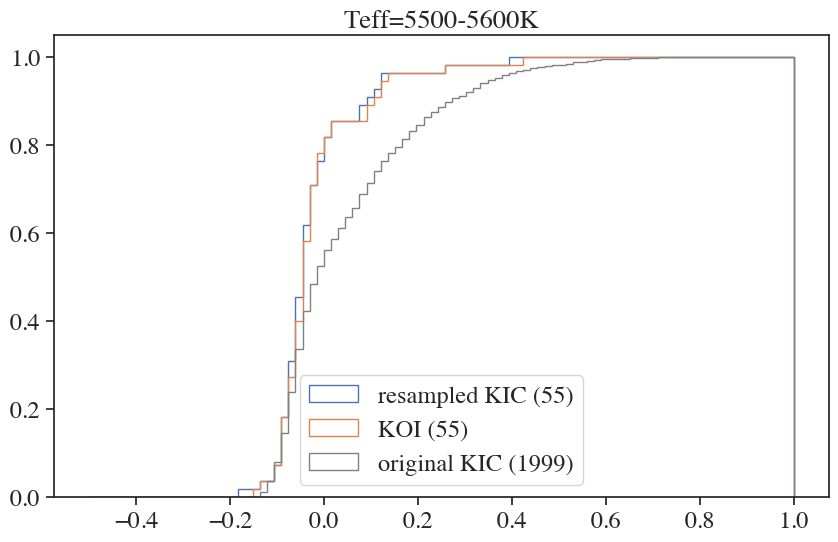

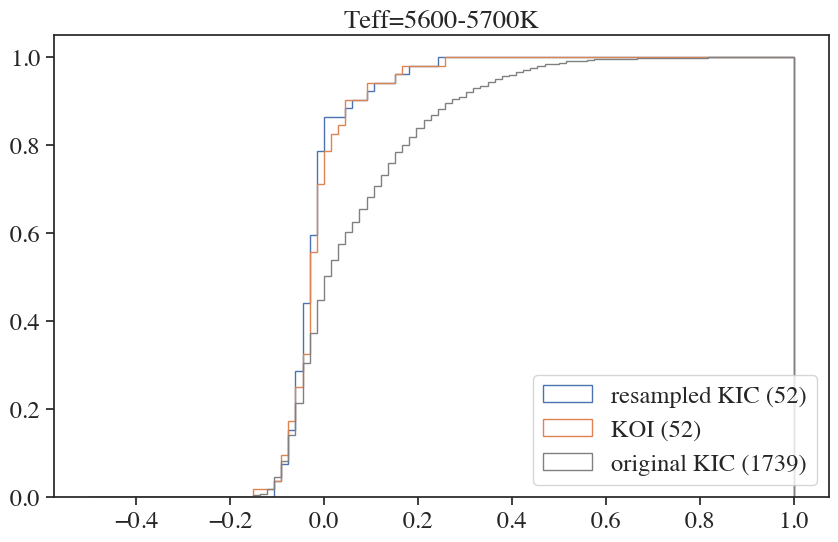

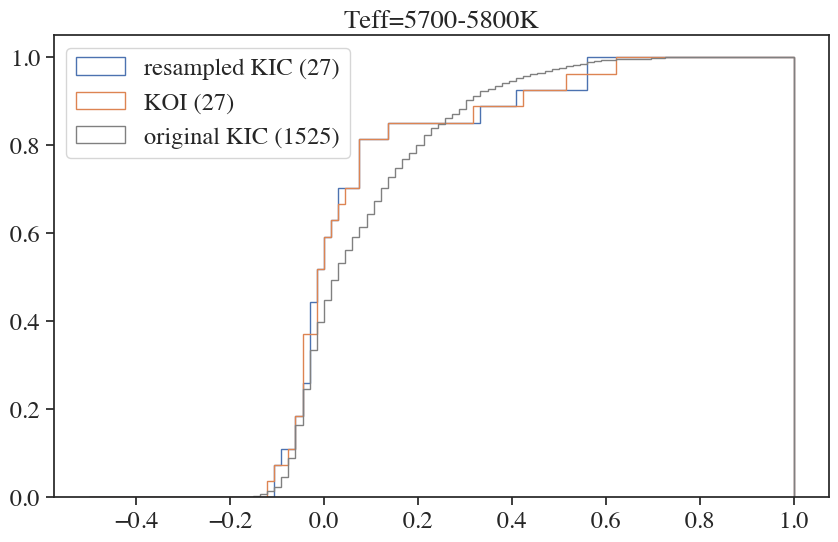

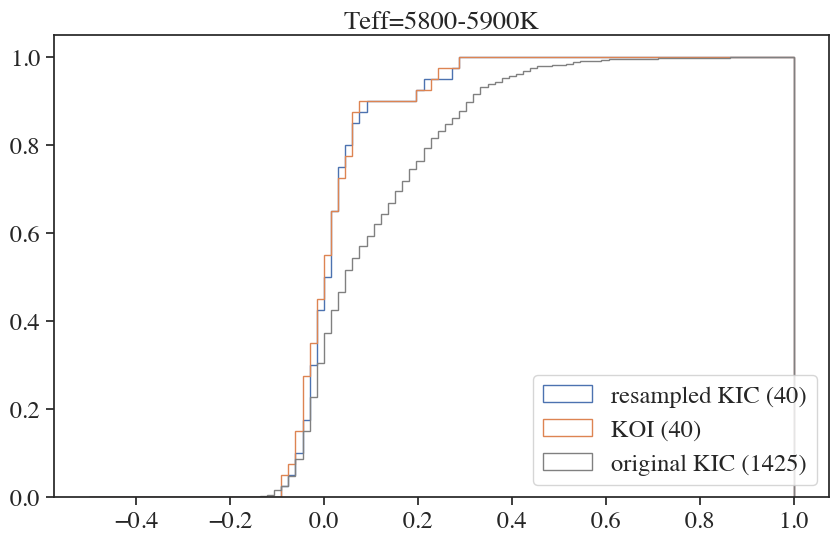

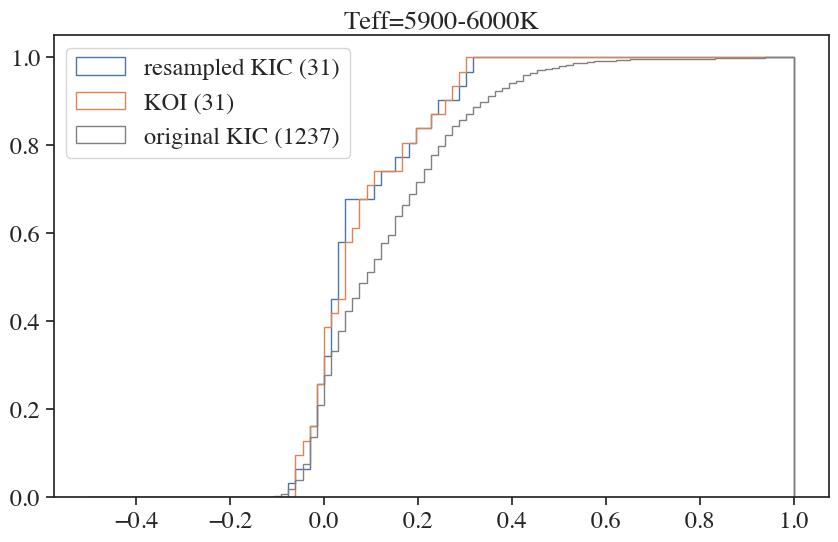

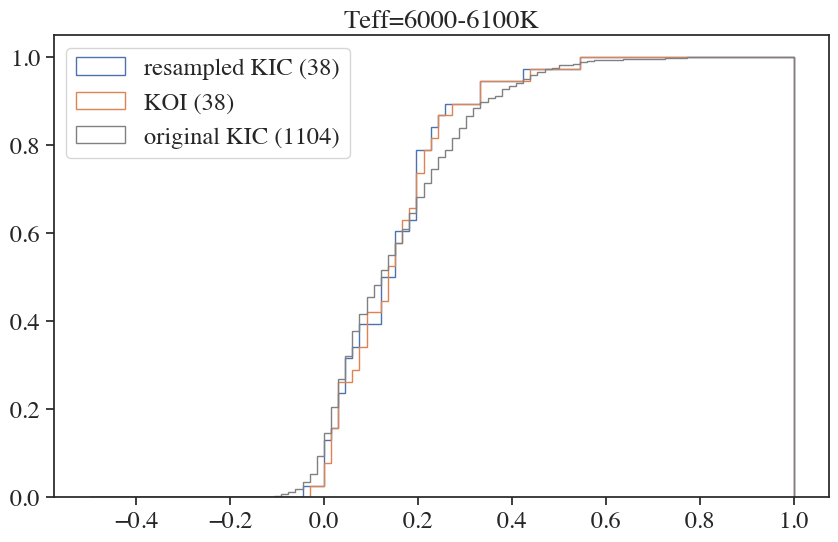

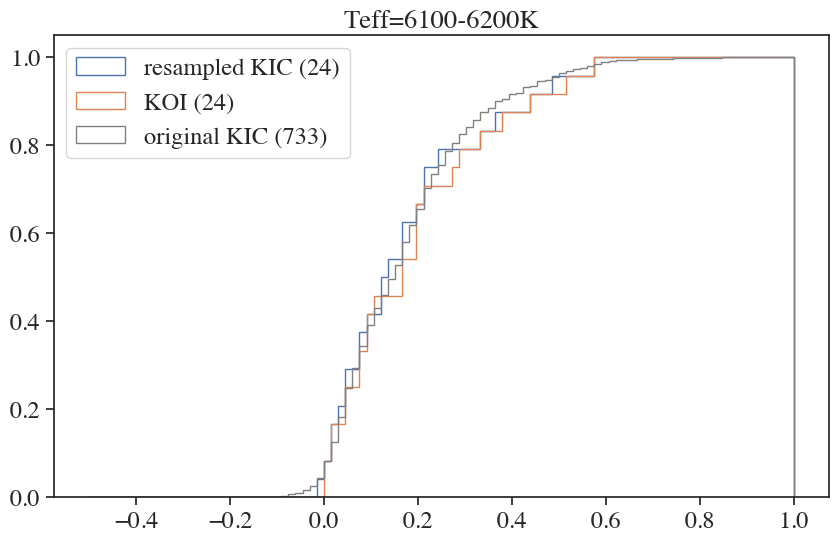

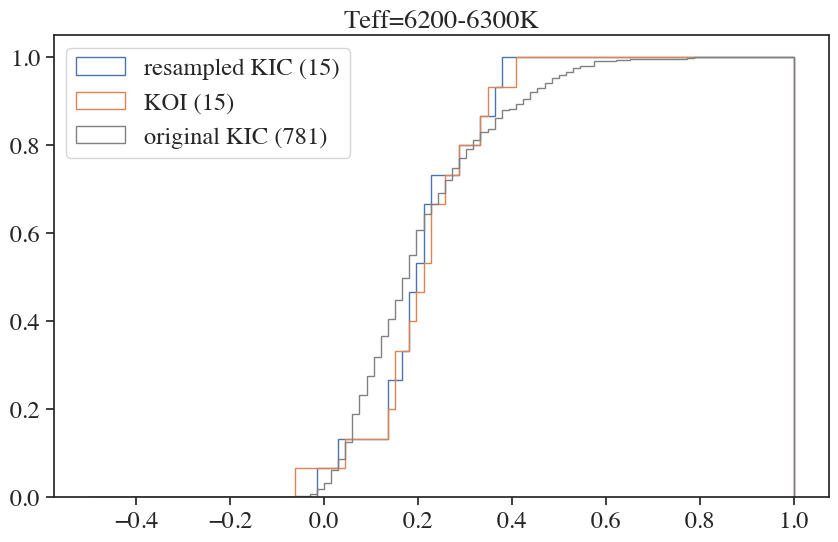

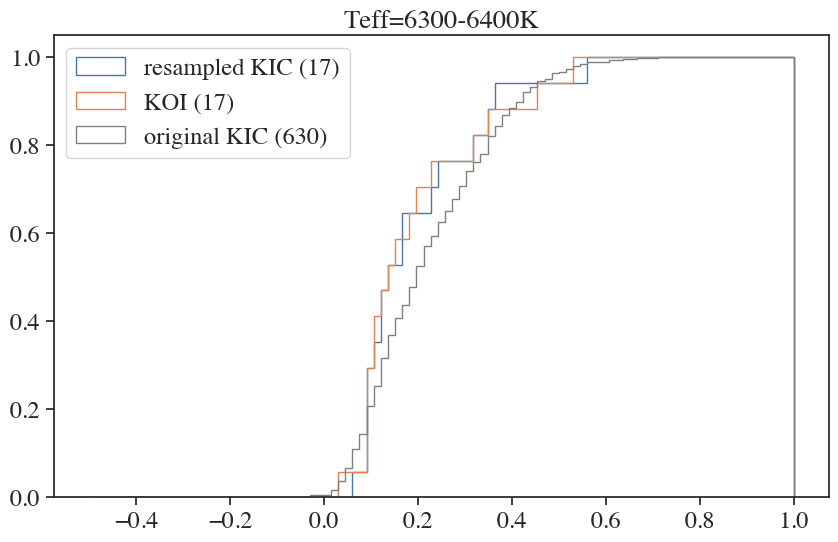

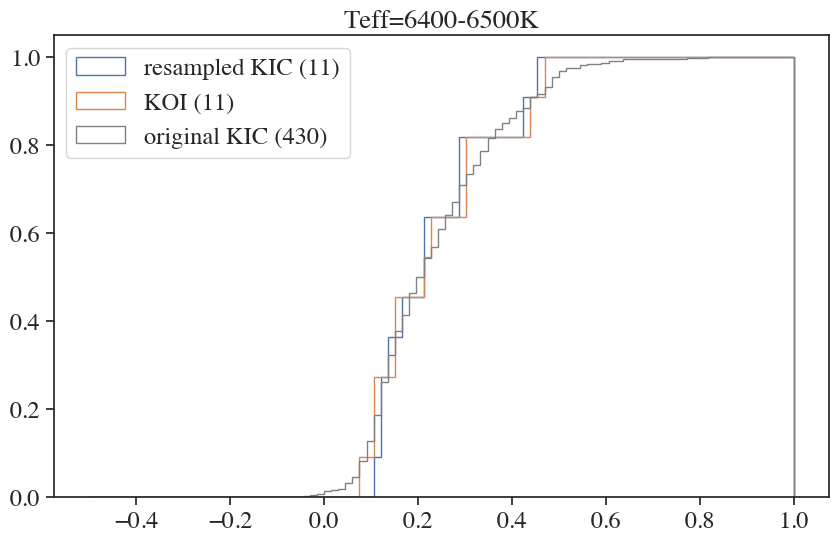

In [8]:
check_rad_dists(dkic_smp, dkoi, teff_bins, dkic_orig=dkic)

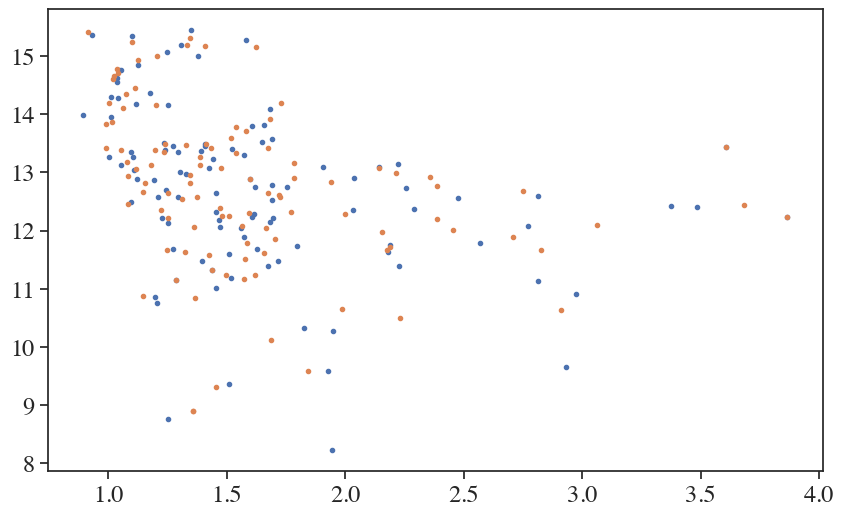

In [9]:
idx = dkoi.Teff > 6000
plt.plot(dkoi.rad[idx], dkoi.kepmag[idx], '.')
idx = dkic_smp.Teff > 6000
plt.plot(dkic_smp.rad[idx], dkic_smp.kepmag[idx], '.')

In [10]:
dkic_rs_list = []
for i in range(200):
    dkic_pi = sample_dkic_pi(dkic, pdetsampler)
    dkic_rs_list.append(get_resampled_kic(dkic_pi, dkoi, teff_bins))

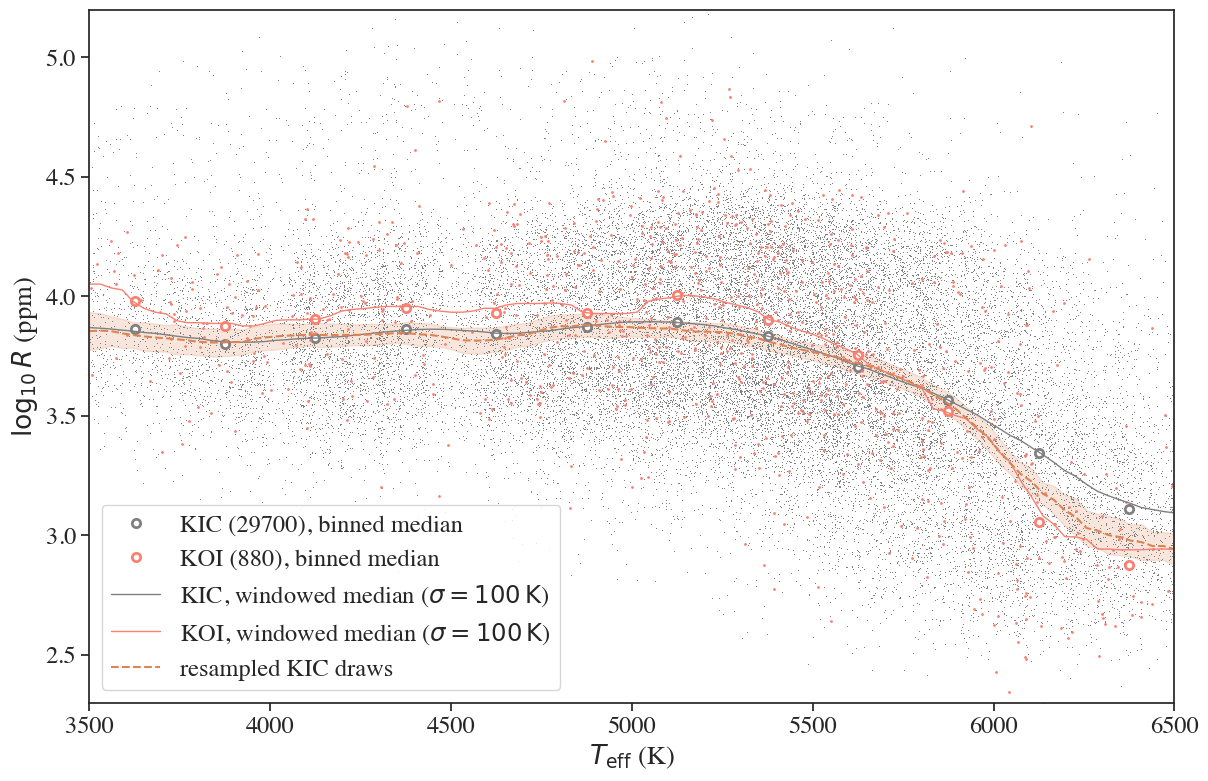

In [11]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list)
plt.savefig("figs/m15_pdet_magrad_weighted.png", dpi=200, bbox_inches="tight")

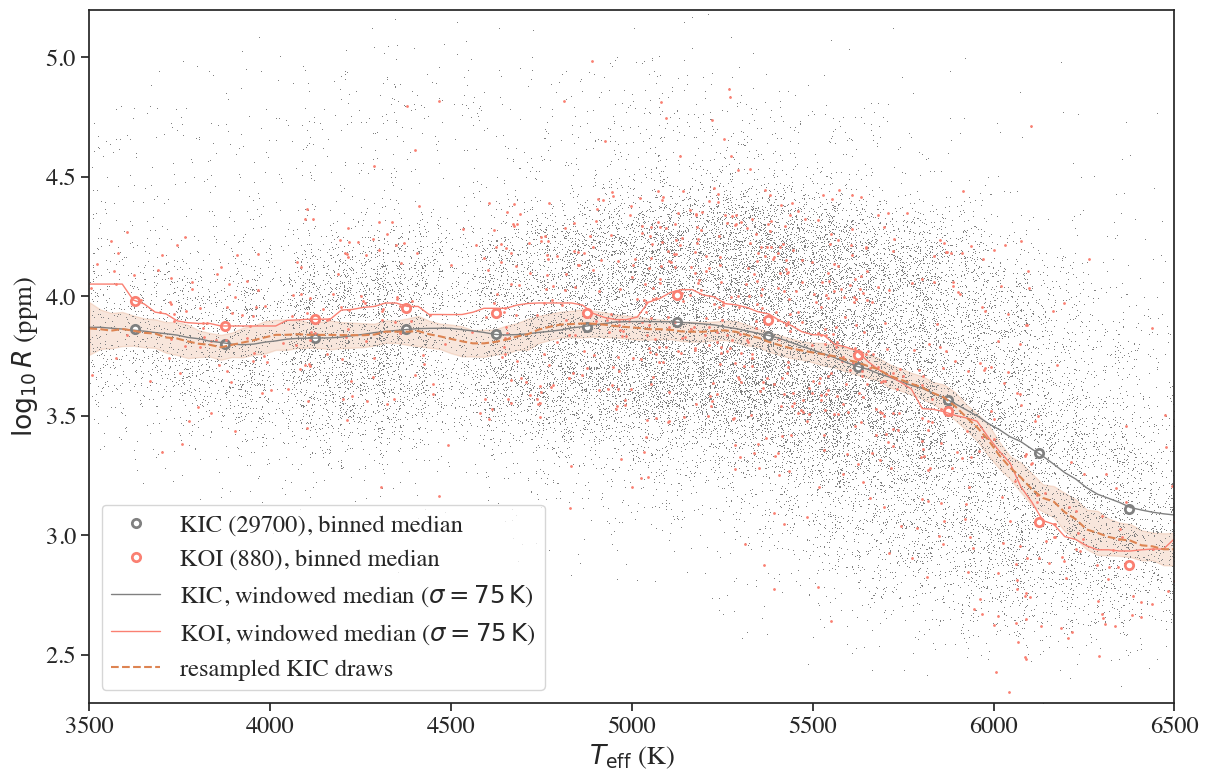

In [16]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, teff_sigma=75)
plt.savefig("figs/m15_pdet_magrad_weighted_s75.png", dpi=200, bbox_inches="tight")

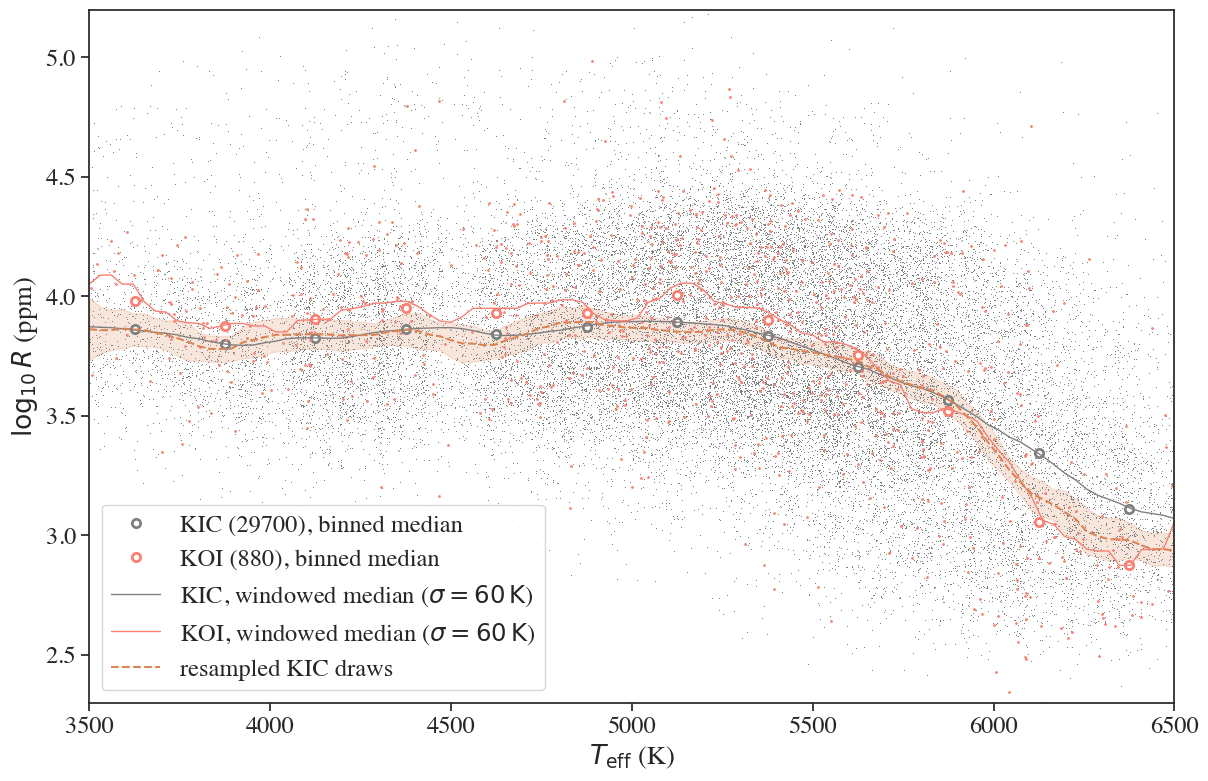

In [15]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, teff_sigma=60)
plt.savefig("figs/m15_pdet_magrad_weighted_s60.png", dpi=200, bbox_inches="tight")

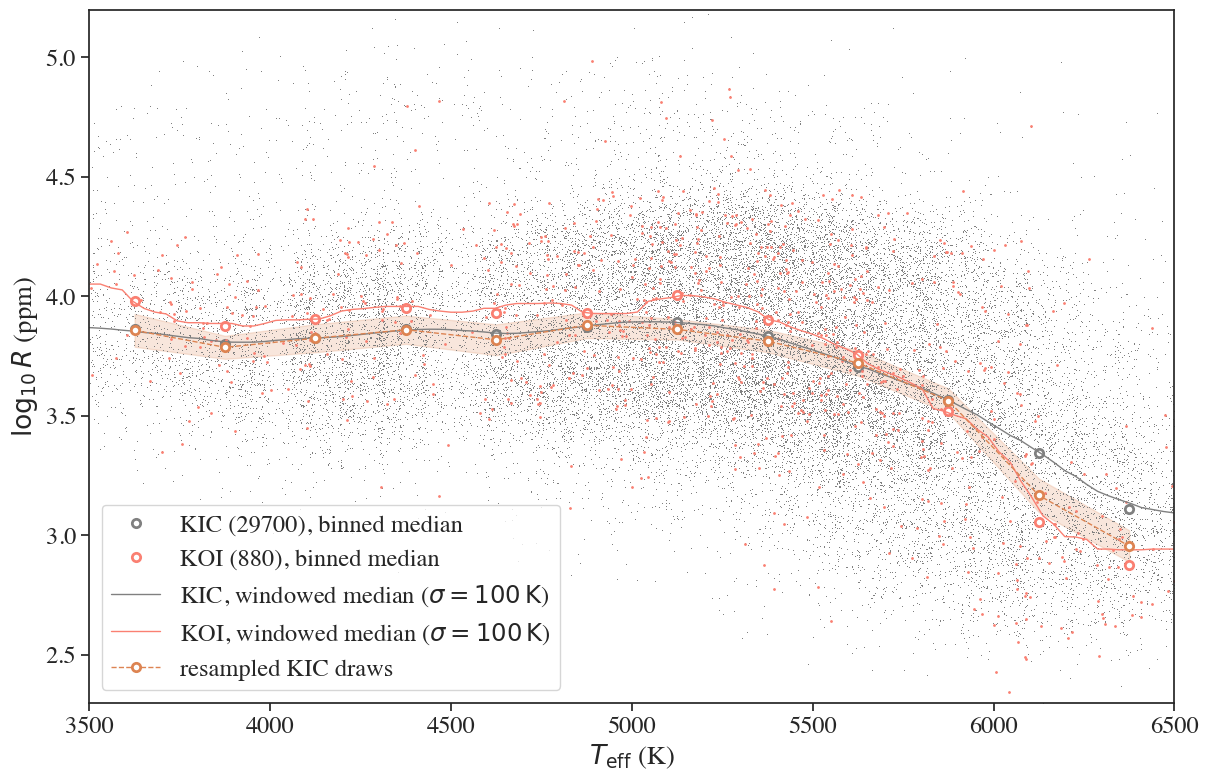

In [12]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, rs_method='binned')
plt.savefig("figs/m15_pdet_magrad_weighted_bin.png", dpi=200, bbox_inches="tight")

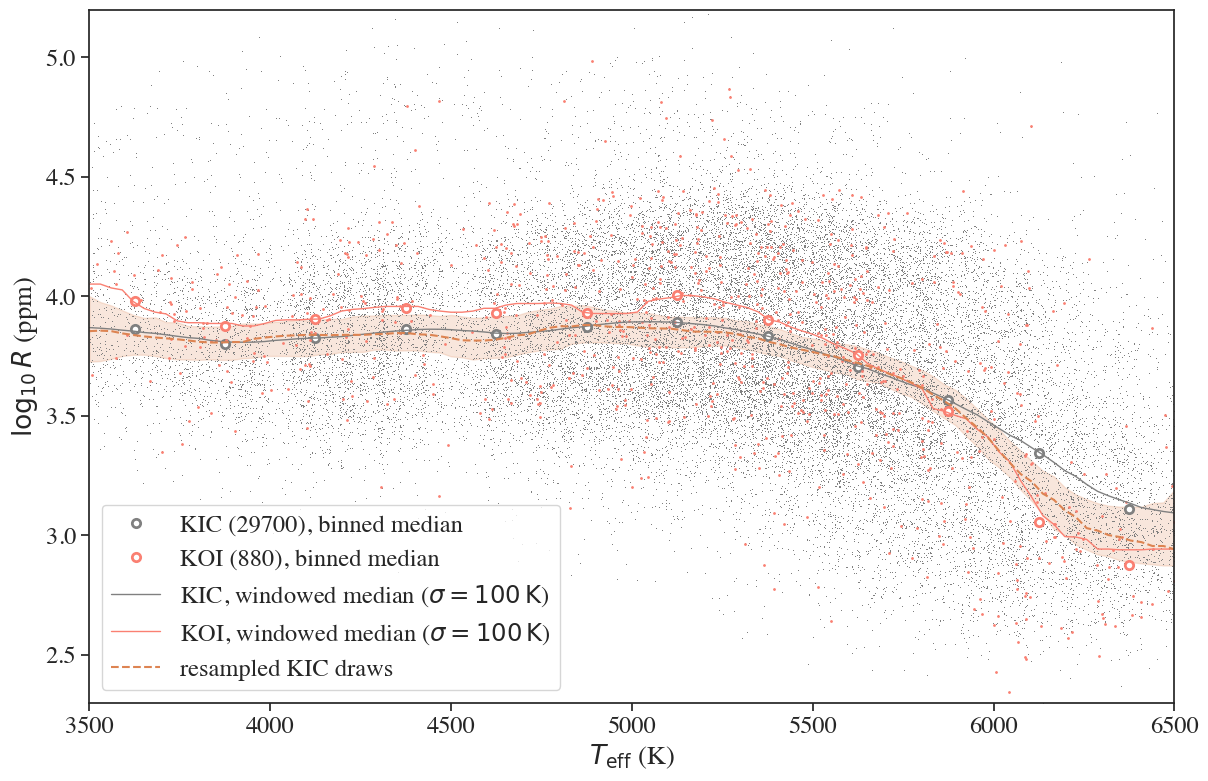

In [14]:
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list, use_pct=True)
plt.savefig("figs/m15_pdet_magrad_weighted_pct90.png", dpi=200, bbox_inches="tight")

## turn off pdet correction

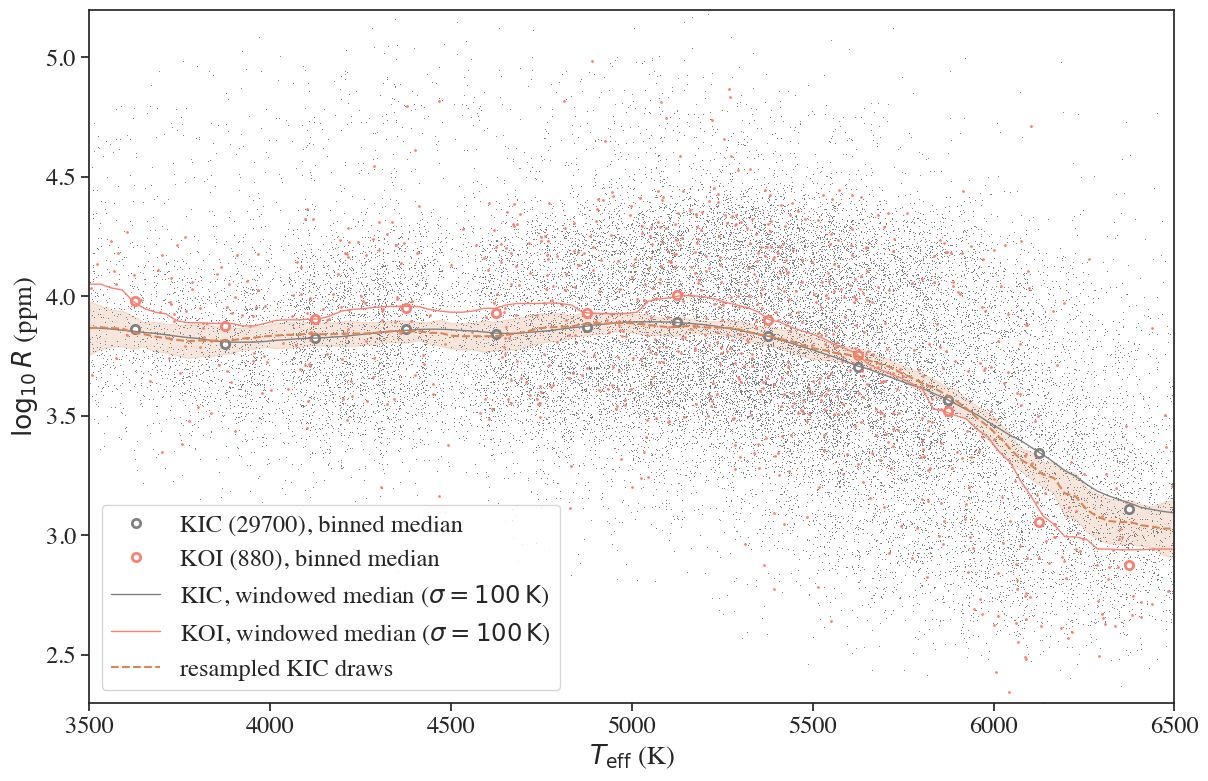

In [22]:
dkic_rs_list = []
for i in range(100):
    dkic_rs_list.append(get_resampled_kic(dkic, dkoi, teff_bins))
fig = plot_list(dkic, dkoi, dkic_list=dkic_rs_list)
plt.savefig("figs/m15_magrad_weighted.png", dpi=200, bbox_inches="tight")

## reweight KOI to KIC

In [28]:
def resample_dkoi(dkic, dkoi, pdetsampler):
    teff_bins = np.arange(3500, 6501, 150)

    pdet = pdetsampler.sample(dkoi.logr, dkoi.kepmag, dkoi.Teff, dkoi.rad)
    pdet = np.fmax(pdet, 1e-2)
    piD = 1. / pdet

    idx = np.random.choice(np.arange(len(dkoi)), size=len(dkoi), p=piD/np.sum(piD))
    dkoi_pi = dkoi.iloc[idx].reset_index(drop=True)

    dkoi_pi_res = sample_near_dkoiR(dkoi_pi, dkic, teff_bins, size_like='dkic')

    return dkoi_pi, dkoi_pi_res

In [31]:
dkoi_res_list = []
for i in range(500):
    dkoi_pi, dkoi_pi_res = resample_dkoi(dkic, dkoi, pdetsampler)
    dkoi_res_list.append(dkoi_pi_res)

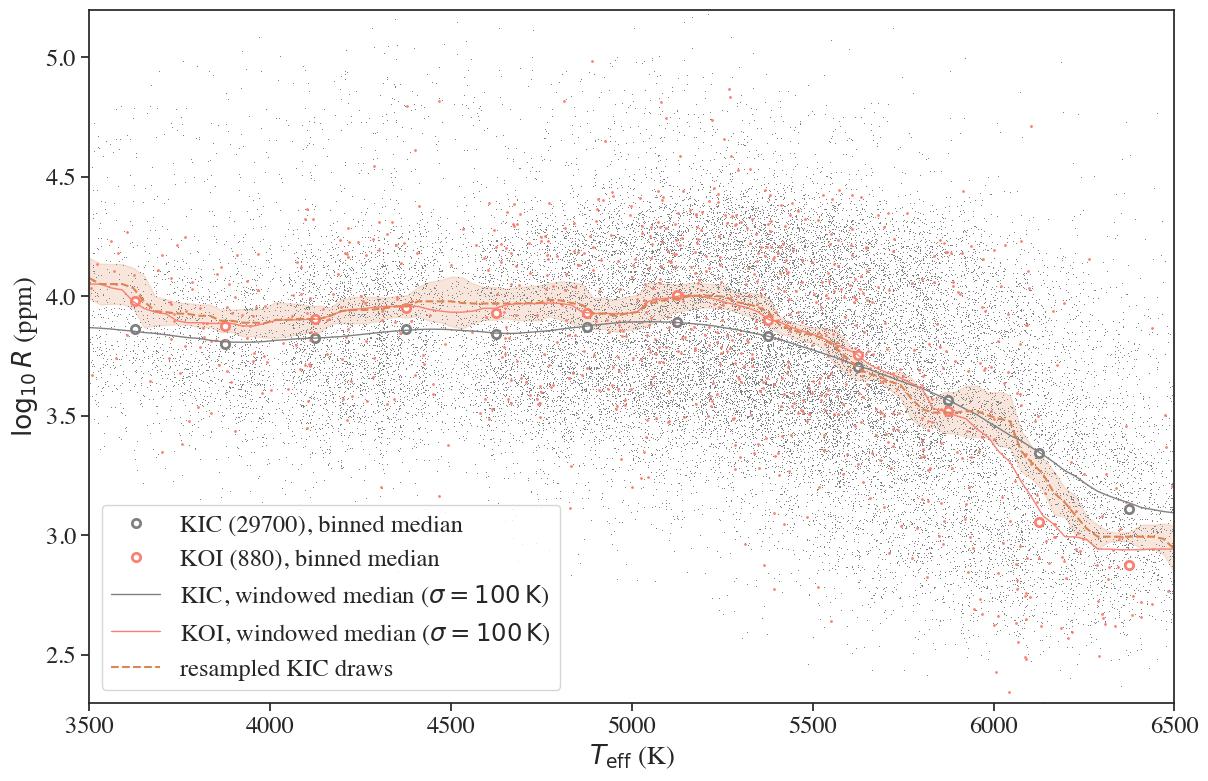

In [33]:
fig = plot_list(dkic, dkoi, dkic_list=dkoi_res_list)
plt.savefig("figs/m15_pdet_magrad_weighted_koi-to-kic.png", dpi=200, bbox_inches='tight');